# An interpretable machine learning framework for predicting and optimizing DNA synthesis difficulty 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
import warnings
from collections import Counter
from PIL import Image
import os
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

## 1. Input and Data Preprocessing
The input data consists of BGI's gene synthesis order records from 2026. Each order contains order placement time and delivery time, from which we can derive the synthesis duration (Duration) for each order, which can also be understood as synthesis difficulty. In addition to synthesis difficulty, the table also contains sequence information, secondary structure data (Vienna), minimum free energy (MFE) of the secondary structure, sequence length, the vector used, and difficulty predictions (L1–L4) from previous methods.

Next, we will calculate various features of the DNA sequences, including both primary and secondary structures. This is because gene synthesis difficulty is fundamentally determined by these features.

#### 1.1 Initial data loading and inspection

In [5]:
# Load the data
df = pd.read_excel('训练基因信息_features.xlsx', header=0)

# Clean data: remove rows with NaN or non-string sequences
df_clean = df[
    df['Sequence'].notna()  # Exclude NaN
    & df['Sequence'].apply(lambda x: isinstance(x, str))  # Exclude non-strings
].copy()

# SHUFFLE THE DATA
print(f"Original data shape: {df_clean.shape}")
print(f"Original index range: {df_clean.index.min()} to {df_clean.index.max()}")

# Shuffle the dataset with a fixed random seed for reproducibility
df_shuffled = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n Data shuffled!")
print(f"New data shape: {df_shuffled.shape}")
print(f"New index range: {df_shuffled.index.min()} to {df_shuffled.index.max()}")

# Assign back to df
df = df_shuffled

# Show first few rows to verify
print("\n First 5 rows after shuffling:")
print(df.head())

Original data shape: (1677, 13)
Original index range: 0 to 1676

 Data shuffled!
New data shape: (1677, 13)
New index range: 0 to 1676

 First 5 rows after shuffling:
     ID                                           Sequence  Length  Duration  \
0  1601  ATGAACCGCGTGAGCCTGTATCCGCCGACCCTGGATGGTAACAGCG...    1908         7   
1   483  GGATCCATGCGTCCGACCGCTATTGTTGCTGCCGCGCTGGGTTGCT...     777         5   
2   204  catatgAGCGTTACCACCCCACGTCGTGGTAGCCGTGAAAGCAGCC...     852         7   
3    50  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     417         5   
4  1290  CTCGAGAGGAAGAACTCGCAGGGAGGAAAGCAGAACTGGAGGAAGC...    5676        62   

                                    Vienna Structure  MFE (kcal/mol)  \
0  .......(((.((.......))))).(((..((((((((..(((((...          -543.7   
1  ...((((.((((((((((....((.((((.((((((((((((.(((...          -306.5   
2  ...(((.((((((((((........)))))))).......((((.(...          -323.5   
3  .(((((((((....((.(((.((((((((....))))))))....)...          -1

#### 1.2 Log trasformer and data structure inspection

AUTOMATIC LENGTH ANALYSIS WITH OUTLIER REMOVAL

📁 File: 训练基因信息_features.xlsx
📊 Original shape: 1677 rows × 13 columns

✅ Using length column: 'Length'

AUTOMATIC OUTLIER DETECTION & REMOVAL

📊 Outlier Detection Results:
   IQR Method (1.5×IQR):     197 outliers (11.75%)
   Z-Score Method (>3σ):     56 outliers (3.34%)
   Isolation Forest (5%):    84 outliers (5.01%)

AUTOMATIC OUTLIER REMOVAL STRATEGY

📊 Removing 84 outliers using combined method (detected by ≥2 methods)
   Outlier length range: 6361.00 - 12181.00
   Outlier length stats: mean=9255.76, std=1722.78

   First 5 outliers detected:
     Row 1025: length=6361.00
     Row 1026: length=6361.00
     Row 1027: length=7157.00
     Row 1028: length=7157.00
     Row 1029: length=7221.00

✅ Dataset after removal: 1593 rows (removed 84 rows)
   Index reset: 0 to 1592

LENGTH STATISTICS COMPARISON

Metric          Before       After        Change      
---------------------------------------------------
Count           1677         1

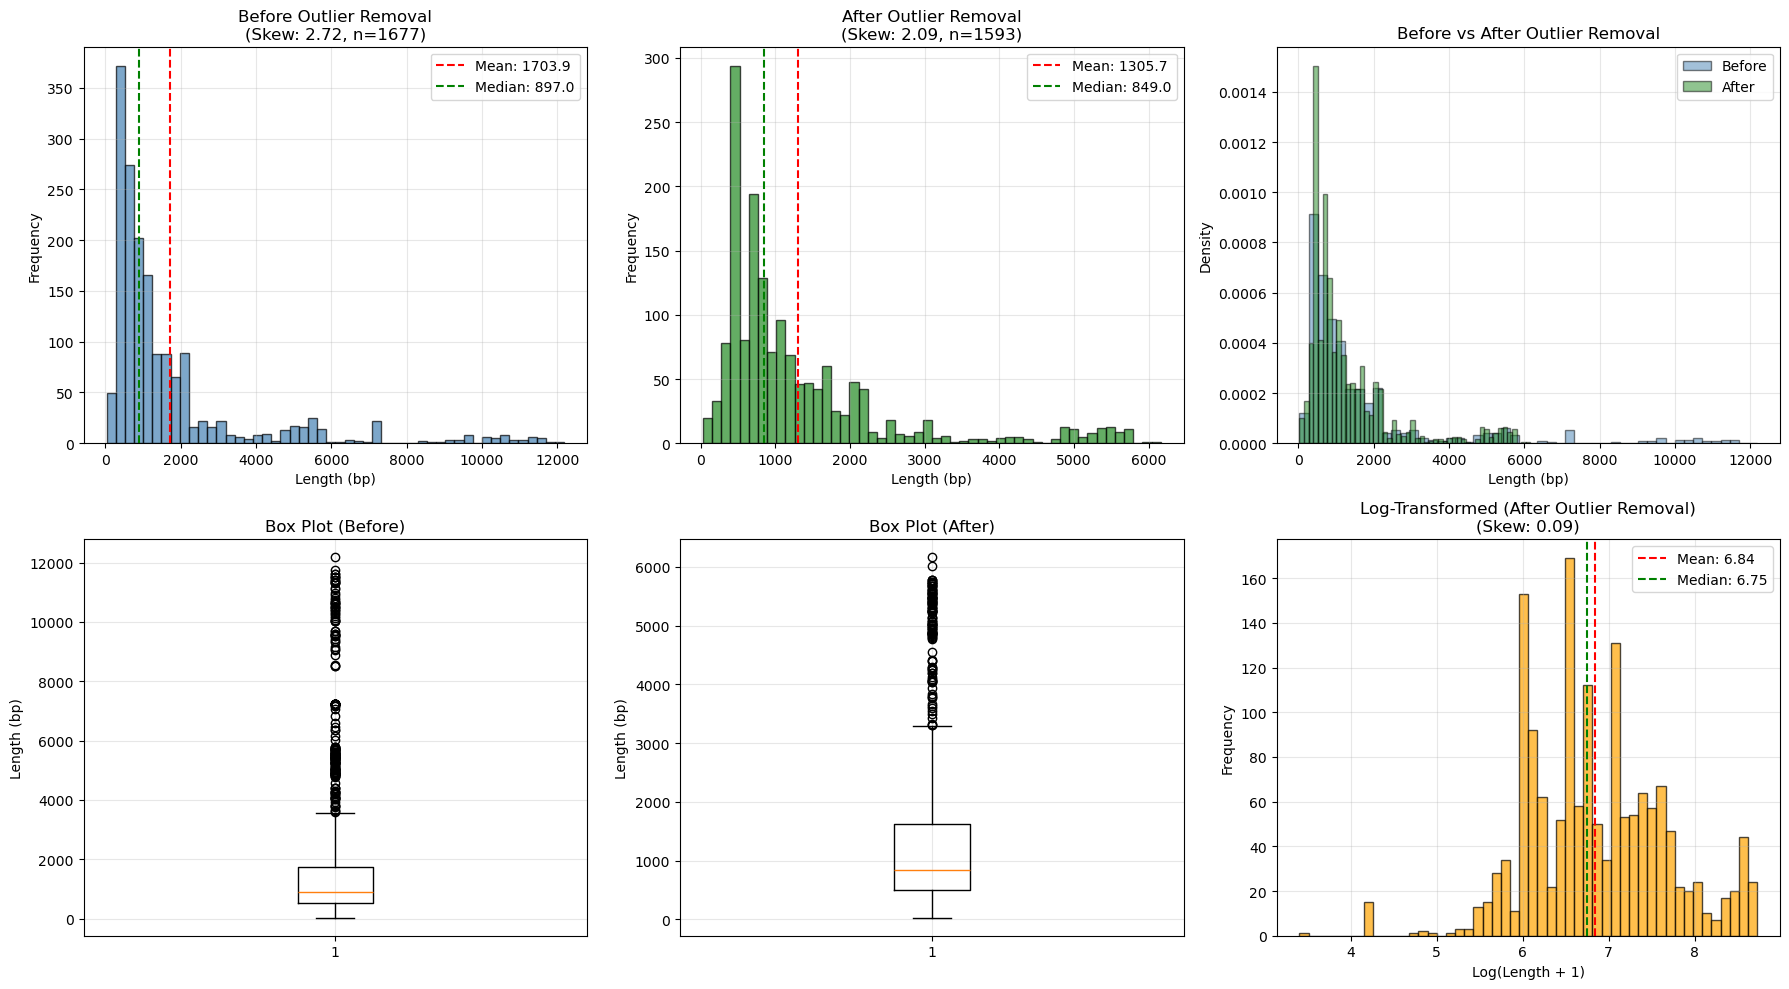


✅ Visualization saved as: length_analysis_automatic_outlier_removal.png

LOG TRANSFORMATION
   Used: log(length)

📊 Log-Transformed Length Statistics:
   Mean: 6.8379
   Median: 6.7441
   Min: 3.3673
   Max: 8.7262
   Std: 0.8111

ADDITIONAL LENGTH-BASED FEATURES
   ✅ Added: sqrt_length
   ✅ Added: length_ratio
   ✅ Added: length_category
   ✅ Added: length_zscore

CORRELATION WITH TARGET: 'Duration'
   Original Length: 0.8327
   Log Length: 0.6744
   Sqrt Length: 0.7832
   Length Ratio: 0.8327
   Length Z-Score: 0.8327

✅ Best transformation: Original Length (r = 0.8327)

✅ Clean dataset saved to: sequences_with_features_clean.csv
✅ Original dataset with outlier flags saved to: sequences_with_features_outliers_marked.csv

SUMMARY

📊 Dataset Summary:
   Original data: 1677 rows
   After outlier removal: 1593 rows
   Removed: 84 rows (5.01%)
   Outlier removal method: Combined (IQR + Z-Score + Isolation Forest)

📊 Length Statistics After Removal:
   Mean: 1305.66
   Median: 849.00
   S

In [6]:
# ============================================================================
# LENGTH DISTRIBUTION ANALYSIS & LOG TRANSFORMATION WITH AUTOMATIC OUTLIER REMOVAL
# ============================================================================

warnings.filterwarnings('ignore')

# ============================================================================
# 1. LOAD YOUR DATA
# ============================================================================

# Load your dataset
file_path = '训练基因信息_features.xlsx'
df = pd.read_excel(file_path)

print("=" * 70)
print("AUTOMATIC LENGTH ANALYSIS WITH OUTLIER REMOVAL")
print("=" * 70)
print(f"\n📁 File: {file_path}")
print(f"📊 Original shape: {df.shape[0]} rows × {df.shape[1]} columns")

# ============================================================================
# 2. IDENTIFY LENGTH COLUMN
# ============================================================================

# Try to find the length column
length_col = None
for col in ['长度', 'Length', 'length', '序列长度', 'len', 'sequence_length']:
    if col in df.columns:
        length_col = col
        break

# If not found, try to find a numeric column with values in range 100-5000
if length_col is None:
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            if 100 < df[col].median() < 5000:
                length_col = col
                break

if length_col is None:
    print(f"\n⚠️ Could not find length column. Available columns: {df.columns.tolist()}")
    raise ValueError("Length column not found. Please check your data.")

print(f"\n✅ Using length column: '{length_col}'")

# ============================================================================
# 3. AUTOMATIC OUTLIER DETECTION AND REMOVAL
# ============================================================================

length_data = df[length_col].dropna()

print("\n" + "=" * 70)
print("AUTOMATIC OUTLIER DETECTION & REMOVAL")
print("=" * 70)

# Method 1: IQR Method (1.5×IQR)
Q1 = length_data.quantile(0.25)
Q3 = length_data.quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR
iqr_outliers = length_data[(length_data < iqr_lower) | (length_data > iqr_upper)]

# Method 2: Z-Score Method (3 standard deviations)
z_scores = np.abs(stats.zscore(length_data))
z_outliers = length_data[z_scores > 3]

# Method 3: Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso_forest.fit_predict(length_data.values.reshape(-1, 1))
iso_outliers = length_data[iso_pred == -1]

print(f"\n📊 Outlier Detection Results:")
print(f"   IQR Method (1.5×IQR):     {len(iqr_outliers)} outliers ({len(iqr_outliers)/len(length_data)*100:.2f}%)")
print(f"   Z-Score Method (>3σ):     {len(z_outliers)} outliers ({len(z_outliers)/len(length_data)*100:.2f}%)")
print(f"   Isolation Forest (5%):    {len(iso_outliers)} outliers ({len(iso_outliers)/len(length_data)*100:.2f}%)")

# ============================================================================
# 4. AUTOMATIC OUTLIER REMOVAL STRATEGY
# ============================================================================

print("\n" + "=" * 70)
print("AUTOMATIC OUTLIER REMOVAL STRATEGY")
print("=" * 70)

# Get indices of outliers from each method (convert to lists)
iqr_indices = list(iqr_outliers.index.tolist())
z_indices = list(z_outliers.index.tolist())
iso_indices = list(iso_outliers.index.tolist())

# Convert to sets for intersection/union operations
iqr_set = set(iqr_indices)
z_set = set(z_indices)
iso_set = set(iso_indices)

# Combined: Outliers detected by at least 2 methods
combined_outliers = iqr_set.intersection(z_set).union(
    iqr_set.intersection(iso_set)
).union(
    z_set.intersection(iso_set)
)

# Also include extreme outliers (detected by all 3 methods)
extreme_outliers = iqr_set.intersection(z_set).intersection(iso_set)

# Final outlier mask: Remove all outliers detected by at least 2 methods
outlier_indices = combined_outliers

# If no outliers found by combined method, use IQR method as fallback
if len(outlier_indices) == 0:
    print("\n⚠️ No outliers detected by combined method. Using IQR method.")
    outlier_indices = iqr_set

# Convert to list for easier handling
outlier_indices_list = list(outlier_indices)

# Create mask
outlier_mask = df.index.isin(outlier_indices_list)
num_outliers = outlier_mask.sum()

print(f"\n📊 Removing {num_outliers} outliers using combined method (detected by ≥2 methods)")

if num_outliers > 0:
    outlier_lengths = df.loc[outlier_mask, length_col]
    print(f"   Outlier length range: {outlier_lengths.min():.2f} - {outlier_lengths.max():.2f}")
    print(f"   Outlier length stats: mean={outlier_lengths.mean():.2f}, std={outlier_lengths.std():.2f}")
    
    # Show first few outliers (convert to list first)
    print(f"\n   First 5 outliers detected:")
    for idx in outlier_indices_list[:5]:
        print(f"     Row {idx}: length={df.loc[idx, length_col]:.2f}")
else:
    print("\n✅ No outliers detected. Keeping all data.")

# Remove outliers
df_clean = df[~outlier_mask].copy()

# ✅ RESET THE INDEX - THIS FIXES THE DISCREPANCY
df_clean = df_clean.reset_index(drop=True)

print(f"\n✅ Dataset after removal: {len(df_clean)} rows (removed {len(df) - len(df_clean)} rows)")
print(f"   Index reset: 0 to {len(df_clean)-1}")

# ============================================================================
# 5. LENGTH DISTRIBUTION ANALYSIS (BEFORE AND AFTER)
# ============================================================================

length_clean = df_clean[length_col].dropna()

print("\n" + "=" * 70)
print("LENGTH STATISTICS COMPARISON")
print("=" * 70)

print(f"\n{'Metric':<15} {'Before':<12} {'After':<12} {'Change':<12}")
print("-" * 51)
print(f"{'Count':<15} {len(length_data):<12} {len(length_clean):<12} {len(length_data)-len(length_clean):<12}")
print(f"{'Mean':<15} {length_data.mean():<12.2f} {length_clean.mean():<12.2f} {length_clean.mean()-length_data.mean():<12.2f}")
print(f"{'Median':<15} {length_data.median():<12.2f} {length_clean.median():<12.2f} {length_clean.median()-length_data.median():<12.2f}")
print(f"{'Std':<15} {length_data.std():<12.2f} {length_clean.std():<12.2f} {length_clean.std()-length_data.std():<12.2f}")
print(f"{'Min':<15} {length_data.min():<12.2f} {length_clean.min():<12.2f} {length_clean.min()-length_data.min():<12.2f}")
print(f"{'Max':<15} {length_data.max():<12.2f} {length_clean.max():<12.2f} {length_clean.max()-length_data.max():<12.2f}")
print(f"{'Skewness':<15} {length_data.skew():<12.4f} {length_clean.skew():<12.4f} {length_clean.skew()-length_data.skew():<12.4f}")

# ============================================================================
# 6. VISUALIZE BEFORE AND AFTER
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 6a. Histogram before
axes[0, 0].hist(length_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(length_data.mean(), color='red', linestyle='--', label=f'Mean: {length_data.mean():.1f}')
axes[0, 0].axvline(length_data.median(), color='green', linestyle='--', label=f'Median: {length_data.median():.1f}')
axes[0, 0].set_xlabel('Length (bp)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Before Outlier Removal\n(Skew: {length_data.skew():.2f}, n={len(length_data)})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 6b. Histogram after
axes[0, 1].hist(length_clean, bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(length_clean.mean(), color='red', linestyle='--', label=f'Mean: {length_clean.mean():.1f}')
axes[0, 1].axvline(length_clean.median(), color='green', linestyle='--', label=f'Median: {length_clean.median():.1f}')
axes[0, 1].set_xlabel('Length (bp)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'After Outlier Removal\n(Skew: {length_clean.skew():.2f}, n={len(length_clean)})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6c. Before vs After overlay
axes[0, 2].hist(length_data, bins=50, color='steelblue', edgecolor='black', alpha=0.5, label='Before', density=True)
axes[0, 2].hist(length_clean, bins=50, color='forestgreen', edgecolor='black', alpha=0.5, label='After', density=True)
axes[0, 2].set_xlabel('Length (bp)')
axes[0, 2].set_ylabel('Density')
axes[0, 2].set_title('Before vs After Outlier Removal')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 6d. Box plot before
axes[1, 0].boxplot(length_data, vert=True)
axes[1, 0].set_ylabel('Length (bp)')
axes[1, 0].set_title('Box Plot (Before)')
axes[1, 0].grid(True, alpha=0.3)

# 6e. Box plot after
axes[1, 1].boxplot(length_clean, vert=True)
axes[1, 1].set_ylabel('Length (bp)')
axes[1, 1].set_title('Box Plot (After)')
axes[1, 1].grid(True, alpha=0.3)

# 6f. Log-transformed after removal
log_clean = np.log(length_clean + 1)
axes[1, 2].hist(log_clean, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 2].axvline(log_clean.mean(), color='red', linestyle='--', label=f'Mean: {log_clean.mean():.2f}')
axes[1, 2].axvline(log_clean.median(), color='green', linestyle='--', label=f'Median: {log_clean.median():.2f}')
axes[1, 2].set_xlabel('Log(Length + 1)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title(f'Log-Transformed (After Outlier Removal)\n(Skew: {log_clean.skew():.2f})')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('length_analysis_automatic_outlier_removal.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as: length_analysis_automatic_outlier_removal.png")

# ============================================================================
# 7. APPLY LOG TRANSFORMATION
# ============================================================================

print("\n" + "=" * 70)
print("LOG TRANSFORMATION")
print("=" * 70)

# Check if there are zero or negative values
min_val = df_clean[length_col].min()
if min_val <= 0:
    df_clean['log_length'] = np.log(df_clean[length_col] + 1)
    print(f"   Used: log(length + 1)  (because min value = {min_val:.2f} ≤ 0)")
else:
    df_clean['log_length'] = np.log(df_clean[length_col])
    print(f"   Used: log(length)")

print(f"\n📊 Log-Transformed Length Statistics:")
print(f"   Mean: {df_clean['log_length'].mean():.4f}")
print(f"   Median: {df_clean['log_length'].median():.4f}")
print(f"   Min: {df_clean['log_length'].min():.4f}")
print(f"   Max: {df_clean['log_length'].max():.4f}")
print(f"   Std: {df_clean['log_length'].std():.4f}")

# ============================================================================
# 8. ADDITIONAL FEATURES
# ============================================================================

print("\n" + "=" * 70)
print("ADDITIONAL LENGTH-BASED FEATURES")
print("=" * 70)

# Square root transformation
df_clean['sqrt_length'] = np.sqrt(df_clean[length_col])
print(f"   ✅ Added: sqrt_length")

# Length ratio (relative to mean)
df_clean['length_ratio'] = df_clean[length_col] / df_clean[length_col].mean()
print(f"   ✅ Added: length_ratio")

# Length categories
df_clean['length_category'] = pd.cut(
    df_clean[length_col],
    bins=[0, 300, 600, 900, 1200, 1500, 2000, 5000],
    labels=['very_short', 'short', 'medium', 'medium_long', 'long', 'very_long', 'extreme']
)
print(f"   ✅ Added: length_category")

# Normalized length (z-score)
df_clean['length_zscore'] = (df_clean[length_col] - df_clean[length_col].mean()) / df_clean[length_col].std()
print(f"   ✅ Added: length_zscore")

# ============================================================================
# 9. CORRELATION WITH TARGET (if available)
# ============================================================================

# Try to find target column
target_col = None
for col in ['完成周期', 'Duration', 'duration', '实际交付周期', 'time', 'Time', 'target', 'y']:
    if col in df_clean.columns:
        target_col = col
        break

if target_col:
    print("\n" + "=" * 70)
    print(f"CORRELATION WITH TARGET: '{target_col}'")
    print("=" * 70)
    
    length_features = {
        'Original Length': length_col,
        'Log Length': 'log_length',
        'Sqrt Length': 'sqrt_length',
        'Length Ratio': 'length_ratio',
        'Length Z-Score': 'length_zscore'
    }
    
    correlations = {}
    for name, col in length_features.items():
        if col in df_clean.columns:
            corr = df_clean[col].corr(df_clean[target_col])
            correlations[name] = corr
            print(f"   {name}: {corr:.4f}")
    
    # Find best
    if correlations:
        best = max(correlations.items(), key=lambda x: abs(x[1]))
        print(f"\n✅ Best transformation: {best[0]} (r = {best[1]:.4f})")
else:
    print("\n⚠️ Target column not found. Skipping correlation analysis.")

# ============================================================================
# 10. SAVE CLEAN DATASET
# ============================================================================

# Save the clean dataset
output_file = 'sequences_with_features_clean.csv'
df_clean.to_csv(output_file, index=False)
print(f"\n✅ Clean dataset saved to: {output_file}")

# Also save the original with outlier flags for reference
df['is_outlier'] = outlier_mask
df.to_csv('sequences_with_features_outliers_marked.csv', index=False)
print(f"✅ Original dataset with outlier flags saved to: sequences_with_features_outliers_marked.csv")

# ============================================================================
# 11. SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset Summary:")
print(f"   Original data: {len(df)} rows")
print(f"   After outlier removal: {len(df_clean)} rows")
print(f"   Removed: {len(df) - len(df_clean)} rows ({ (len(df) - len(df_clean))/len(df)*100:.2f}%)")
print(f"   Outlier removal method: Combined (IQR + Z-Score + Isolation Forest)")

print(f"\n📊 Length Statistics After Removal:")
print(f"   Mean: {length_clean.mean():.2f}")
print(f"   Median: {length_clean.median():.2f}")
print(f"   Std: {length_clean.std():.2f}")
print(f"   Skewness: {length_clean.skew():.4f}")

print(f"\n📊 New Features Added:")
for col in ['log_length', 'sqrt_length', 'length_ratio', 'length_category', 'length_zscore']:
    if col in df_clean.columns:
        print(f"   - {col}")

# Verify index is reset
print(f"\n📊 Index Verification:")
print(f"   First index: {df_clean.index[0]}")
print(f"   Last index: {df_clean.index[-1]}")
print(f"   Total rows: {len(df_clean)}")
print(f"   ✓ Index matches row count: {len(df_clean) == df_clean.index[-1] + 1}")

print("\n" + "=" * 70)
print("✅ AUTOMATIC OUTLIER REMOVAL AND LOG TRANSFORMATION COMPLETE")
print("=" * 70)

## 2. DNA Feature Extraction
#### 2.1 Nucleotide Composition
First, we count the number of each nucleotide (A, G, C, T) in the DNA sequence and calculate its proportion relative to the total sequence length.

In [7]:
# Build nucleotide composition function (with additional error handling to ensure input is a string)
def base_composition(seq):
    # Double safeguard: ensure input is a string; if not, return all zero ratios
    if not isinstance(seq, str):
        return {'A_ratio': 0.0, 'G_ratio': 0.0, 'C_ratio': 0.0, 'T_ratio': 0.0}
    
    # Convert to uppercase and count nucleotides
    seq_upper = seq.upper()
    counts = Counter(seq_upper)
    total = len(seq_upper)
    
    # Avoid division by zero (if the sequence is an empty string)
    if total == 0:
        return {'A_ratio': 0.0, 'G_ratio': 0.0, 'C_ratio': 0.0, 'T_ratio': 0.0}
    
    return {
        'A_ratio': counts.get('A', 0) / total,
        'G_ratio': counts.get('G', 0) / total,
        'C_ratio': counts.get('C', 0) / total,
        'T_ratio': counts.get('T', 0) / total
    }

# Apply the function to calculate nucleotide composition (using the cleaned dataset)
nucleotide_composition = df_clean['Sequence'].apply(base_composition).apply(pd.Series)

# Merge the calculated results back into the original cleaned dataset
df = pd.concat([df_clean, nucleotide_composition], axis=1)

# View the results
nucleotide_composition

,A_ratio,G_ratio,C_ratio,T_ratio
0,0.223022,0.273381,0.323741,0.179856
1,0.197452,0.278132,0.326964,0.197452
2,0.214765,0.257271,0.326622,0.201342
3,0.191847,0.297362,0.318945,0.191847
4,0.207143,0.283333,0.328571,0.180952
...,...,...,...,...
1588,0.252061,0.296820,0.236749,0.214370
1589,0.252061,0.295642,0.234393,0.217903
1590,0.249706,0.300353,0.229682,0.220259
1591,0.247350,0.299176,0.234393,0.219081


#### 2.2 Dinucleotide Composition
Next, we count the occurrences of all 16 possible dinucleotide combinations (e.g., AA, AG, AC, etc.) in the sequence. Each dinucleotide count is divided by the sequence length minus 1 (the total possible number of dinucleotide occurrences) to calculate the dinucleotide frequency.

In [8]:
from itertools import product
import pandas as pd

def dinucleotide_ratio(seq):
    di_counts = {k: 0 for k in [''.join(p) for p in product('AGCT', repeat=2)]}
    for i in range(len(seq) - 1):
        di = seq[i:i+2]
        if di in di_counts:  
            di_counts[di] += 1
    
    total = len(seq) - 1
    if total > 0:
        return {k: v / total for k, v in di_counts.items()}
    else:
        return di_counts  

di_features = df['Sequence'].apply(dinucleotide_ratio).apply(pd.Series)

di_features

,AA,AG,AC,AT,GA,GG,GC,GT,CA,CG,CC,CT,TA,TG,TC,TT
0,0.038462,0.060096,0.074519,0.043269,0.069712,0.081731,0.084135,0.033654,0.081731,0.048077,0.098558,0.081731,0.024038,0.079327,0.055288,0.016827
1,0.023404,0.057447,0.074468,0.036170,0.059574,0.082979,0.100000,0.031915,0.074468,0.042553,0.089362,0.108511,0.031915,0.091489,0.053191,0.017021
2,0.042601,0.062780,0.062780,0.040359,0.062780,0.065022,0.096413,0.029148,0.073991,0.044843,0.094170,0.100897,0.026906,0.080717,0.062780,0.026906
3,0.024038,0.064904,0.062500,0.033654,0.064904,0.093750,0.096154,0.038462,0.067308,0.048077,0.093750,0.096154,0.026442,0.086538,0.055288,0.019231
4,0.035800,0.062053,0.071599,0.031026,0.066826,0.088305,0.083532,0.040573,0.071599,0.042959,0.109785,0.090692,0.023866,0.085919,0.052506,0.014320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588,0.087264,0.055425,0.030660,0.075472,0.070755,0.063679,0.125000,0.037736,0.054245,0.087264,0.053066,0.042453,0.036557,0.090802,0.028302,0.057783
1589,0.087264,0.055425,0.030660,0.075472,0.070755,0.060142,0.121462,0.043632,0.053066,0.088443,0.054245,0.038915,0.037736,0.091981,0.028302,0.058962
1590,0.084906,0.056604,0.029481,0.075472,0.070755,0.063679,0.122642,0.043632,0.051887,0.087264,0.048349,0.042453,0.038915,0.093160,0.029481,0.057783
1591,0.080189,0.055425,0.033019,0.075472,0.074292,0.061321,0.121462,0.042453,0.053066,0.087264,0.053066,0.041274,0.036557,0.095519,0.027123,0.058962


#### 2.3 k-mer (k=3) Composition
We then use the CountVectorizer tool to decompose the sequence into 3-mers (e.g., AAA, AAC, etc.) and count the occurrences of each 3-mer. Each k-mer count is divided by the sequence length minus 2 (the total possible number of 3-mer occurrences) to calculate the k-mer frequency.

In [23]:
import pandas as pd

# Sequence cleaning function: keep only A/G/C/T (uppercase), remove other characters
def clean_sequence(seq):
    if pd.isna(seq):  # Handle NaN
        return ''
    # Keep only A/G/C/T and convert to uppercase
    return ''.join([c.upper() for c in str(seq) if c.upper() in {'A', 'G', 'C', 'T'}])

# Clean all sequences and filter out empty strings
df['Clean_Sequence'] = df['Sequence'].apply(clean_sequence)
sequences = df['Clean_Sequence'][df['Clean_Sequence'] != ''].tolist()

# Generate 3-mer counts (uppercase A/G/C/T)
cv = CountVectorizer(
    analyzer='char', 
    ngram_range=(3, 3),
    token_pattern=r'[AGCT]{3}'  # Only match uppercase A/G/C/T combinations
)
kmer_counts = cv.fit_transform(sequences)

# Calculate k-mer frequency (count / (sequence length - 2))
kmer_freq = []
for i, seq in enumerate(sequences):
    seq_len = len(seq)
    if seq_len >= 3:
        freq = kmer_counts[i].toarray()[0] / (seq_len - 2)  # Frequency normalization
    else:
        freq = [0] * len(cv.get_feature_names_out())
    kmer_freq.append(freq)

# Create DataFrame (column names like 'AAA', 'AAG', ...)
kmer_df = pd.DataFrame(
    kmer_freq,
    columns=cv.get_feature_names_out()  # Column names are uppercase 3-mer combinations
)

kmer_df

,aaa,aac,aag,aat,aca,acc,acg,act,aga,agc,...,tcg,tct,tga,tgc,tgg,tgt,tta,ttc,ttg,ttt
0,0.004819,0.012048,0.012048,0.009639,0.024096,0.038554,0.007229,0.007229,0.021687,0.024096,...,0.007229,0.026506,0.021687,0.012048,0.036145,0.009639,0.002410,0.007229,0.004819,0.002410
1,0.006397,0.002132,0.010661,0.004264,0.021322,0.034115,0.012793,0.008529,0.017058,0.031983,...,0.006397,0.027719,0.019190,0.023454,0.038380,0.010661,0.000000,0.008529,0.004264,0.004264
2,0.006742,0.013483,0.013483,0.008989,0.020225,0.022472,0.004494,0.017978,0.020225,0.033708,...,0.013483,0.022472,0.024719,0.017978,0.026966,0.011236,0.000000,0.015730,0.004494,0.006742
3,0.004819,0.000000,0.014458,0.004819,0.016867,0.033735,0.007229,0.007229,0.016867,0.028916,...,0.014458,0.021687,0.019277,0.012048,0.043373,0.012048,0.002410,0.009639,0.002410,0.004819
4,0.007177,0.007177,0.014354,0.007177,0.019139,0.045455,0.002392,0.007177,0.021531,0.028708,...,0.007177,0.021531,0.021531,0.011962,0.040670,0.011962,0.002392,0.009569,0.000000,0.002392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588,0.031877,0.011806,0.017710,0.025974,0.002361,0.020071,0.008264,0.000000,0.010626,0.031877,...,0.003542,0.012987,0.036600,0.020071,0.022432,0.011806,0.015348,0.010626,0.012987,0.018890
1589,0.031877,0.011806,0.017710,0.025974,0.002361,0.021251,0.007084,0.000000,0.010626,0.031877,...,0.003542,0.012987,0.036600,0.021251,0.020071,0.014168,0.016529,0.010626,0.012987,0.018890
1590,0.031877,0.010626,0.016529,0.025974,0.002361,0.018890,0.005903,0.002361,0.011806,0.030697,...,0.003542,0.012987,0.036600,0.020071,0.023613,0.012987,0.016529,0.010626,0.011806,0.018890
1591,0.029516,0.009445,0.016529,0.024793,0.002361,0.021251,0.008264,0.001181,0.011806,0.029516,...,0.003542,0.011806,0.038961,0.021251,0.021251,0.014168,0.012987,0.010626,0.015348,0.020071


#### 2.4 Repeat Sequence Analysis
We analyze the number and length of repetitive subsequences within the DNA sequence. The length and density of repeats may affect DNA secondary structure and consequently determine synthesis difficulty. In this study, we define the minimum repeat subsequence length as 4 bp. We identify repeat subsequences of length ≥ 4 bp and calculate the maximum repeat length and repeat density (total repeat length divided by total sequence length).

In [21]:
import pandas as pd
from collections import Counter
from joblib import Parallel, delayed

# 优化后的重复检测函数
def find_repeats_optimized(seq, min_len=4):
    repeats = {}
    n = len(seq)
    for l in range(min_len, n // 2):  # 枚举子串长度
        substrings = (seq[i:i+l] for i in range(n - l + 1))  # 生成所有长度为 l 的子串
        counts = Counter(substrings)  # 一次性统计
        for k, v in counts.items():
            if v > 1:
                repeats[k] = v
    return {
        'max_repeat_len': max((len(k) for k in repeats.keys()), default=0),
        'repeat_density': len(repeats) / n
    }

# 并行处理所有序列
def extract_repeat_features(sequences, min_len=4, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(find_repeats_optimized)(seq, min_len) for seq in sequences
    )
    return pd.DataFrame(results)

# 应用到你的数据
repeat_features = extract_repeat_features(df['Sequence'], min_len=4)
repeat_features

,max_repeat_len,repeat_density
0,8,0.532374
1,10,0.611465
2,11,0.572707
3,8,0.532374
4,8,0.561905
...,...,...
1588,11,0.745583
1589,11,0.746761
1590,11,0.736160
1591,11,0.747939


Finally, we compile all DNA primary structure features together.

In [26]:
length = df['length'].copy()
length.name = 'log_length'

primary_features = pd.concat([
    length,
    nucleotide_composition,
    di_features,
    kmer_df,
    repeat_features,
], axis=1)

print(primary_features.shape)
primary_features.head()

(1593, 87)


,log_length,A_ratio,G_ratio,C_ratio,T_ratio,AA,AG,AC,AT,GA,...,tga,tgc,tgg,tgt,tta,ttc,ttg,ttt,max_repeat_len,repeat_density
0,6.033086,0.223022,0.273381,0.323741,0.179856,0.038462,0.060096,0.074519,0.043269,0.069712,...,0.021687,0.012048,0.036145,0.009639,0.002410,0.007229,0.004819,0.002410,8,0.532374
1,6.154858,0.197452,0.278132,0.326964,0.197452,0.023404,0.057447,0.074468,0.036170,0.059574,...,0.019190,0.023454,0.038380,0.010661,0.000000,0.008529,0.004264,0.004264,10,0.611465
2,6.102559,0.214765,0.257271,0.326622,0.201342,0.042601,0.062780,0.062780,0.040359,0.062780,...,0.024719,0.017978,0.026966,0.011236,0.000000,0.015730,0.004494,0.006742,11,0.572707
3,6.033086,0.191847,0.297362,0.318945,0.191847,0.024038,0.064904,0.062500,0.033654,0.064904,...,0.019277,0.012048,0.043373,0.012048,0.002410,0.009639,0.002410,0.004819,8,0.532374
4,6.040255,0.207143,0.283333,0.328571,0.180952,0.035800,0.062053,0.071599,0.031026,0.066826,...,0.021531,0.011962,0.040670,0.011962,0.002392,0.009569,0.000000,0.002392,8,0.561905


#### 2.5 Secondary Structure
We parse the secondary structure annotation (Vienna format) of the DNA sequence to extract stem-loop structural features. These include: number of stems (stem_count), maximum stem length (max_stem_length), average stem length (avg_stem_length), total number of loops (total_loops), size of the largest loop region in bases (max_loop_size), number of G-T wobble pairs (GT_pairs), and pairing rate (pairing_rate).



In [27]:
# 1. Map the CSV's secondary column names to canonical names (non-destructive) ---
col_map = {
    'MFE (kcal/mol)': 'MFE',
    'Max Stem Length': 'max_stem_length',
    'Avg Stem Length': 'avg_stem_length',
    'Total Loops': 'total_loops',
    'Max Loop Size': 'max_loop_size',
    'GU Pairs': 'GT_pairs',
    'Pairing Rate': 'pairing_rate',
    'Stem Count': 'stem_count',
    # keep previous generic mappings too
    'Vienna Structure': 'vienna',
    'Vienna': 'vienna',
    'log_length': 'length',
    'sequence': 'Sequence'
}
# Only rename columns that exist to avoid KeyError
existing_map = {k: v for k, v in col_map.items() if k in df.columns}
if existing_map:
    df = df.rename(columns=existing_map)
    print("Applied explicit column mapping:", existing_map)

# 2. If the CSV already contains the secondary columns (e.g., exported from another pipeline),
# use them directly; otherwise compute them from parse_vienna. ---
secondary_cols_present = all(c in df.columns for c in [
    'max_stem_length', 'avg_stem_length', 'total_loops',
    'max_loop_size', 'GT_pairs', 'pairing_rate', 'stem_count'
])

if secondary_cols_present:
    # Use the provided columns (coerce types and keep NaN for MFE)
    secondary_features = df[[
        'max_stem_length', 'avg_stem_length', 'total_loops',
        'max_loop_size', 'GT_pairs', 'pairing_rate', 'stem_count'
    ]].copy()
    # Ensure numeric types
    for c in secondary_features.columns:
        secondary_features[c] = pd.to_numeric(secondary_features[c], errors='coerce').fillna(0)
else:
    # Build from parse_vienna output (safe list-comprehension)
    if 'Sequence' not in df.columns:
        raise SystemExit("Input must contain 'Sequence' column.")
    vienna_list = df['vienna'].fillna('').astype(str).tolist() if 'vienna' in df.columns else [''] * len(df)
    seqs = df['Sequence'].astype(str).tolist()
    parsed = [parse_vienna(v, s) for v, s in zip(vienna_list, seqs)]
    parsed_df = pd.DataFrame(parsed, index=df.index)

    secondary_features = pd.DataFrame({
        'max_stem_length': parsed_df.get('stem_lengths', pd.Series([[]]*len(df))).apply(lambda x: max(x) if isinstance(x, (list, tuple)) and x else 0),
        'avg_stem_length': parsed_df.get('stem_lengths', pd.Series([[]]*len(df))).apply(lambda x: float(np.mean(x)) if isinstance(x, (list, tuple)) and x else 0.0),
        'total_loops': parsed_df.get('loop_sizes', pd.Series([[]]*len(df))).apply(lambda x: len(x) if isinstance(x, (list, tuple)) else 0),
        'max_loop_size': parsed_df.get('loop_sizes', pd.Series([[]]*len(df))).apply(lambda x: max(x) if isinstance(x, (list, tuple)) and x else 0),
        'GT_pairs': parsed_df.get('GT_pairs', pd.Series([0]*len(df))).astype(float),
        'pairing_rate': parsed_df.get('pairing_rate', pd.Series([0.0]*len(df))).astype(float),
        'stem_count': parsed_df.get('stem_count', pd.Series([0]*len(df))).astype(int)
    }, index=df.index)

# 3. Attach or coerce MFE column (keep NaN where missing so imputer can handle it) ---
if 'MFE' in df.columns:
    secondary_features['MFE'] = pd.to_numeric(df['MFE'], errors='coerce')
else:
    # if a column named 'MFE (kcal/mol)' existed it was already renamed above;
    # otherwise create MFE column filled with NaN so imputer can fill it later
    secondary_features['MFE'] = np.nan

# 4. Ensure final column order and types ---
expected_cols = [
    'max_stem_length', 'avg_stem_length', 'total_loops',
    'max_loop_size', 'GT_pairs', 'pairing_rate', 'stem_count', 'MFE'
]
# Add any missing expected columns
for c in expected_cols:
    if c not in secondary_features.columns:
        secondary_features[c] = np.nan if c == 'MFE' else 0
# Coerce types
secondary_features['max_stem_length'] = pd.to_numeric(secondary_features['max_stem_length'], errors='coerce').fillna(0).astype(int)
secondary_features['avg_stem_length'] = pd.to_numeric(secondary_features['avg_stem_length'], errors='coerce').fillna(0.0)
secondary_features['total_loops'] = pd.to_numeric(secondary_features['total_loops'], errors='coerce').fillna(0).astype(int)
secondary_features['max_loop_size'] = pd.to_numeric(secondary_features['max_loop_size'], errors='coerce').fillna(0).astype(int)
secondary_features['GT_pairs'] = pd.to_numeric(secondary_features['GT_pairs'], errors='coerce').fillna(0).astype(int)
secondary_features['pairing_rate'] = pd.to_numeric(secondary_features['pairing_rate'], errors='coerce').fillna(0.0)
secondary_features['stem_count'] = pd.to_numeric(secondary_features['stem_count'], errors='coerce').fillna(0).astype(int)
secondary_features['MFE'] = pd.to_numeric(secondary_features['MFE'], errors='coerce')

secondary_features = secondary_features[expected_cols]

# 5. Save secondary_features and combine with your primary_features as you requested ---
secondary_out = "secondary_features.csv"
secondary_features.to_csv(secondary_out, index=False)
print(f"Saved secondary features to {secondary_out} (rows: {len(secondary_features)})")

# Ensure primary_features is a DataFrame (your original code used length = df['Length'].copy(); primary_features = pd.concat([...]))
if isinstance(primary_features, pd.Series):
    primary_df = primary_features.to_frame().reset_index(drop=True)
else:
    primary_df = primary_features.reset_index(drop=True)

all_features = pd.concat([primary_df, secondary_features.reset_index(drop=True)], axis=1)
all_features = all_features.loc[:, ~all_features.columns.duplicated()]

# Save combined table and read back as in your workflow
all_out = "feature_table_with_names.csv"
all_features.to_csv(all_out, index=False)
print(f"Saved combined feature table to {all_out} (rows: {len(all_features)}, cols: {all_features.shape[1]})")

# Optional: read back and describe
all_features = pd.read_csv(all_out, header=0)
print(all_features.describe(include='all').transpose())


Saved secondary features to secondary_features.csv (rows: 1593)
Saved combined feature table to feature_table_with_names.csv (rows: 1593, cols: 95)
                count        mean         std          min         25%  \
log_length     1593.0    6.837937    0.811088     3.367296    6.214608   
A_ratio        1593.0    0.256150    0.054072     0.127036    0.216092   
G_ratio        1593.0    0.274097    0.045268     0.091503    0.246512   
C_ratio        1593.0    0.240214    0.058351     0.088136    0.202112   
T_ratio        1593.0    0.229538    0.047569     0.106406    0.197452   
...               ...         ...         ...          ...         ...   
max_loop_size  1593.0   85.040804   34.867069    11.000000   61.000000   
GT_pairs       1593.0   51.817954   50.350862     0.000000   20.000000   
pairing_rate   1593.0    0.622184    0.041496     0.258065    0.600707   
stem_count     1593.0   93.711237   88.946391     1.000000   38.000000   
MFE            1593.0 -442.193252  451

#### 2.6 Compiling All Sequence Features Together
All extracted features—both primary and secondary structure descriptors—are consolidated into a single comprehensive feature matrix for subsequent model training and analysis.

In [28]:
all_features = pd.concat([primary_features, secondary_features], axis=1)
all_features.to_csv("feature_table_with_names.csv", index=False)
all_features

,log_length,A_ratio,G_ratio,C_ratio,T_ratio,AA,AG,AC,AT,GA,...,max_repeat_len,repeat_density,max_stem_length,avg_stem_length,total_loops,max_loop_size,GT_pairs,pairing_rate,stem_count,MFE
0,6.033086,0.223022,0.273381,0.323741,0.179856,0.038462,0.060096,0.074519,0.043269,0.069712,...,8,0.532374,9,3.818182,7,66,10,0.604317,33,-148.8
1,6.154858,0.197452,0.278132,0.326964,0.197452,0.023404,0.057447,0.074468,0.036170,0.059574,...,10,0.611465,9,4.558824,7,77,14,0.658174,34,-193.2
2,6.102559,0.214765,0.257271,0.326622,0.201342,0.042601,0.062780,0.062780,0.040359,0.062780,...,11,0.572707,8,3.605263,7,92,11,0.612975,38,-145.6
3,6.033086,0.191847,0.297362,0.318945,0.191847,0.024038,0.064904,0.062500,0.033654,0.064904,...,8,0.532374,12,4.758621,10,44,16,0.661871,29,-180.3
4,6.040255,0.207143,0.283333,0.328571,0.180952,0.035800,0.062053,0.071599,0.031026,0.066826,...,8,0.561905,9,3.771429,8,70,10,0.628571,35,-161.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588,6.744059,0.252061,0.296820,0.236749,0.214370,0.087264,0.055425,0.030660,0.075472,0.070755,...,11,0.745583,10,4.218750,17,84,30,0.636042,64,-312.2
1589,6.744059,0.252061,0.295642,0.234393,0.217903,0.087264,0.055425,0.030660,0.075472,0.070755,...,11,0.746761,11,4.234375,15,91,39,0.638398,64,-308.3
1590,6.744059,0.249706,0.300353,0.229682,0.220259,0.084906,0.056604,0.029481,0.075472,0.070755,...,11,0.736160,10,4.156250,16,63,34,0.626620,64,-313.9
1591,6.744059,0.247350,0.299176,0.234393,0.219081,0.080189,0.055425,0.033019,0.075472,0.074292,...,11,0.747939,11,3.956522,13,74,29,0.643110,69,-312.3


In [29]:
all_features = pd.read_csv('feature_table_with_names.csv')
all_features.describe()

,log_length,A_ratio,G_ratio,C_ratio,T_ratio,AA,AG,AC,AT,GA,...,max_repeat_len,repeat_density,max_stem_length,avg_stem_length,total_loops,max_loop_size,GT_pairs,pairing_rate,stem_count,MFE
count,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,...,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000
mean,6.837937,0.256150,0.274097,0.240214,0.229538,0.076360,0.054022,0.045377,0.064144,0.067954,...,23.536723,2.082632,11.942247,4.486727,24.706842,85.040804,51.817954,0.622184,93.711237,-442.193252
std,0.811088,0.054072,0.045268,0.058351,0.047569,0.043352,0.016976,0.017304,0.026962,0.022084,...,65.965967,8.669539,7.010791,1.744546,22.196616,34.867069,50.350862,0.041496,88.946391,451.523359
min,3.367296,0.127036,0.091503,0.088136,0.106406,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,0.045455,4.000000,3.166667,1.000000,11.000000,0.000000,0.258065,1.000000,-2325.200000
25%,6.214608,0.216092,0.246512,0.202112,0.197452,0.043902,0.045345,0.032733,0.045927,0.057604,...,9.000000,0.653409,9.000000,4.108696,11.000000,61.000000,20.000000,0.600707,38.000000,-512.600000
50%,6.744059,0.250883,0.279762,0.233216,0.222117,0.075235,0.054861,0.046092,0.069149,0.068052,...,11.000000,0.722689,11.000000,4.326316,17.000000,77.000000,36.000000,0.624709,63.000000,-293.800000
75%,7.390181,0.289794,0.303571,0.268519,0.253652,0.099951,0.062533,0.057867,0.080595,0.078838,...,13.000000,0.797803,12.000000,4.526316,30.000000,105.000000,65.000000,0.648452,111.000000,-167.900000
max,8.726157,0.614379,0.424561,0.440171,0.440000,0.524590,0.155239,0.107143,0.138462,0.143805,...,657.000000,121.218324,92.000000,22.000000,115.000000,243.000000,285.000000,0.732673,457.000000,-2.200000


#### 2.7 Feature Distribution Analysis
We generated histograms to visualize the frequency distribution of key features within the dataset. This allowed us to understand the range and spread of each feature, identify potential outliers, and assess whether the data exhibited any significant skewness that might require transformation prior to model training.

The histograms provide an overview of how sequence characteristics such as GC content, sequence length, MFE, and stem counts are distributed across the synthesis orders. This preliminary analysis helps contextualize the feature importance results later in the study and ensures that the dataset captures a diverse range of sequence types.



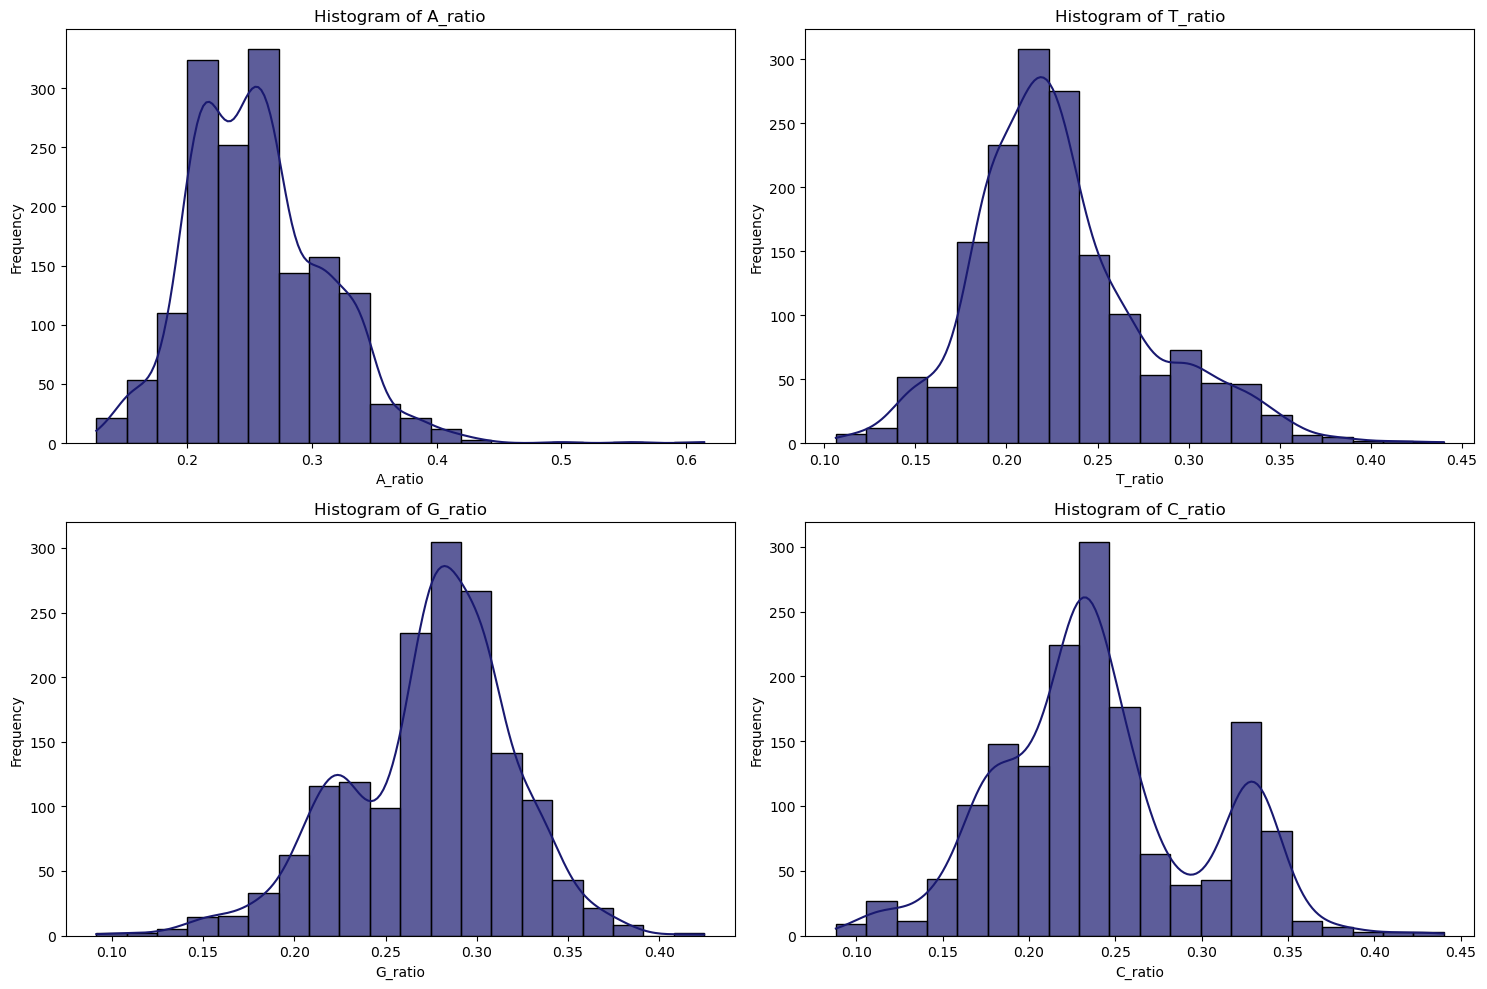

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
num_columns = 4
columns_to_plot = ['A_ratio', 'T_ratio', 'G_ratio', 'C_ratio']

rows = num_columns // 2 + ( 1 if num_columns % 2 != 0 else 0)
for i, column in enumerate(columns_to_plot):
    plt.subplot(rows, 2, i + 1)
    sns.histplot(all_features[column], bins=20, kde=True, alpha=0.7, color='midnightblue')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {column}')

plt.tight_layout()
save_path = r'features_histo.jpg'
plt.savefig(save_path, format='jpg')
plt.show()

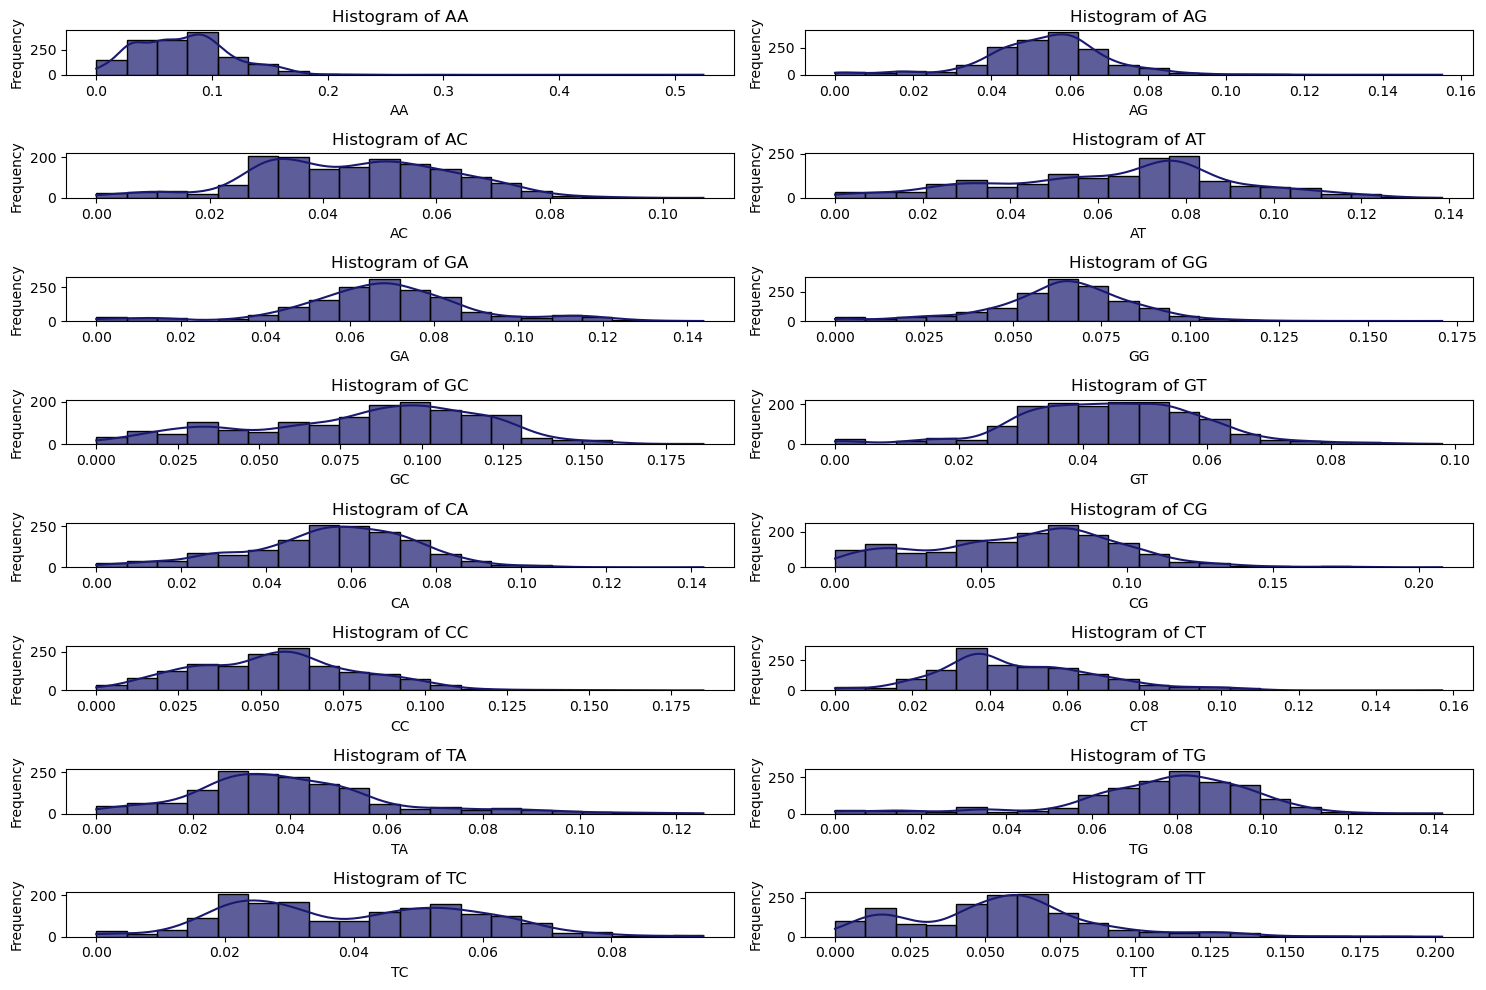

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
num_columns = 16
columns_to_plot = ['AA', 'AG', 'AC', 'AT','GA', 'GG', 'GC', 'GT','CA', 'CG', 'CC', 'CT','TA', 'TG', 'TC', 'TT']

rows = num_columns // 2 + ( 1 if num_columns % 2 != 0 else 0)
for i, column in enumerate(columns_to_plot):
    plt.subplot(rows, 2, i + 1)
    sns.histplot(all_features[column], bins=20, kde=True, alpha=0.7, color='midnightblue')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {column}')

plt.tight_layout()
save_path = r'features_histo.jpg'
plt.savefig(save_path, format='jpg')
plt.show()

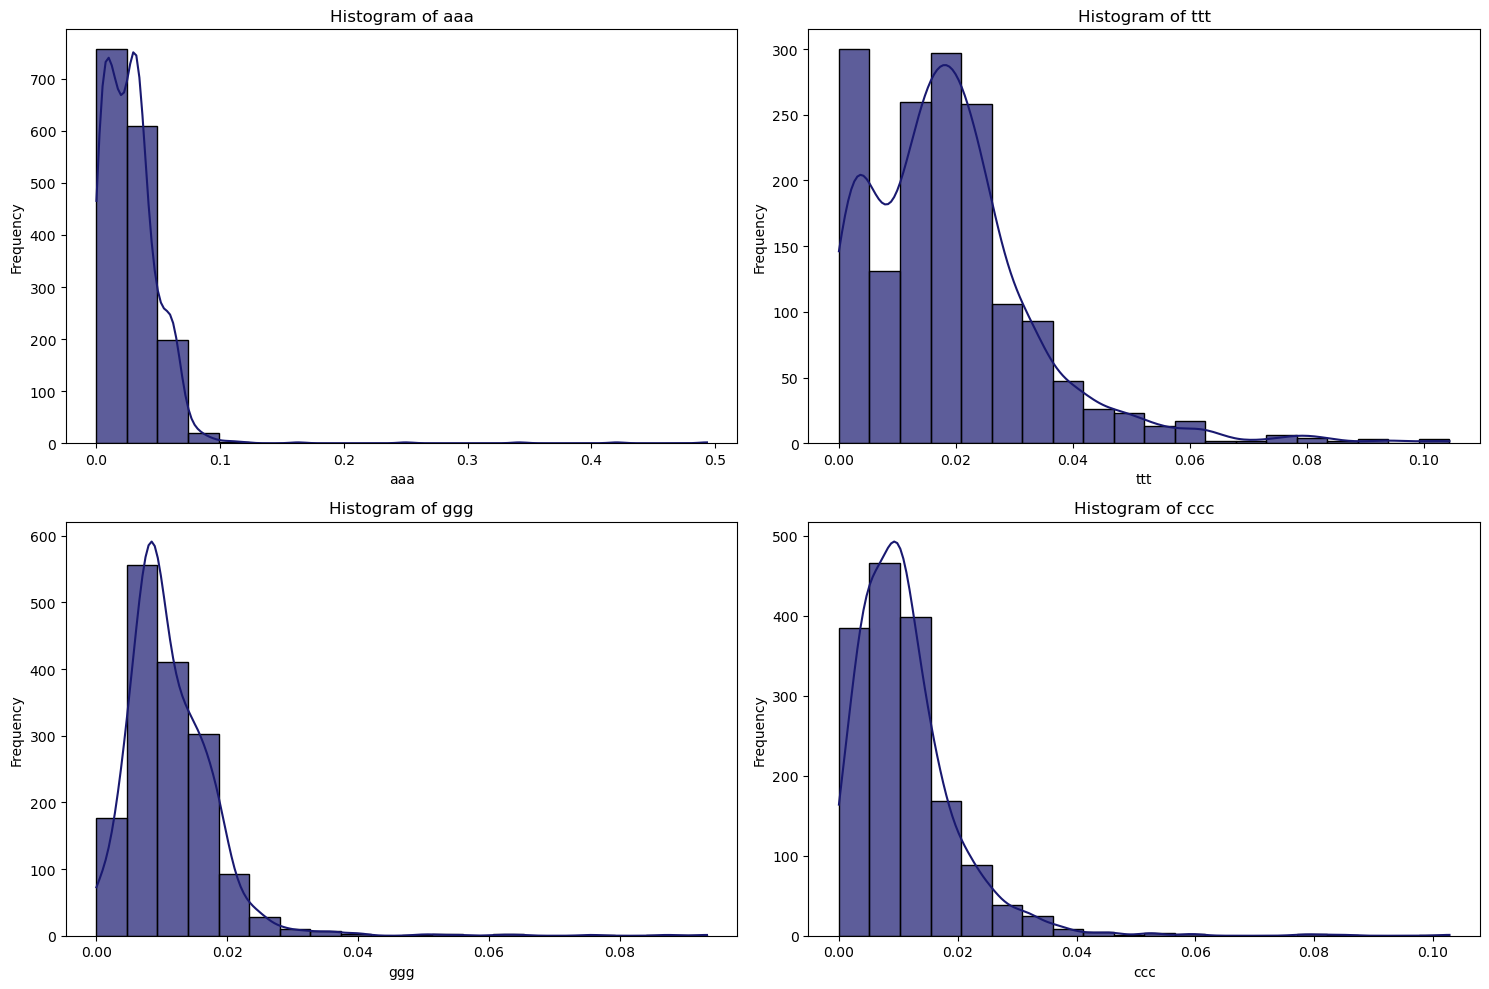

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
num_columns = 4
columns_to_plot = ['aaa', 'ttt', 'ggg', 'ccc']

rows = num_columns // 2 + ( 1 if num_columns % 2 != 0 else 0)
for i, column in enumerate(columns_to_plot):
    plt.subplot(rows, 2, i + 1)
    sns.histplot(all_features[column], bins=20, kde=True, alpha=0.7, color='midnightblue')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {column}')

plt.tight_layout()
save_path = r'features_histo.jpg'
plt.savefig(save_path, format='jpg')
plt.show()

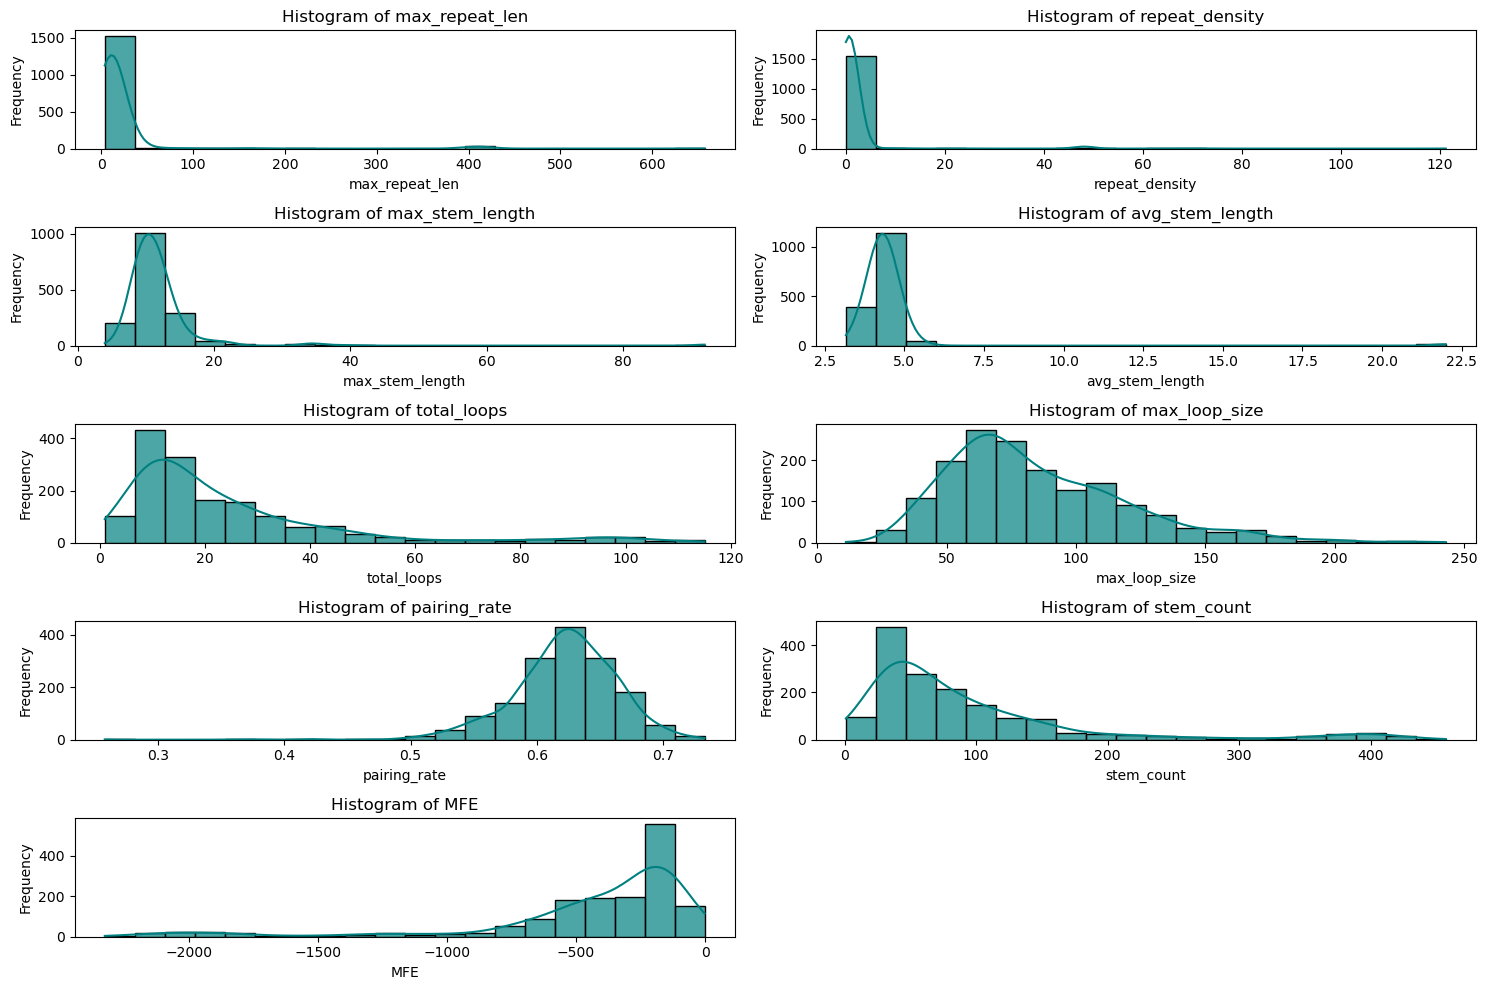

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
num_columns = 10
columns_to_plot = ['max_repeat_len', 'repeat_density', 'max_stem_length', 'avg_stem_length','total_loops', 'max_loop_size', 'pairing_rate','stem_count', 'MFE',]

rows = num_columns // 2 + ( 1 if num_columns % 2 != 0 else 0)
for i, column in enumerate(columns_to_plot):
    plt.subplot(rows, 2, i + 1)
    sns.histplot(all_features[column], bins=20, kde=True, alpha=0.7, color='teal')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {column}')

plt.tight_layout()
save_path = r'features_histo.jpg'
plt.savefig(save_path, format='jpg')
plt.show()

#### 2.8 Feature Correlation Analysis: Clustered Feature Interaction Matrix (Pearson Correlation)
To understand the relationships between features and identify potential multicollinearity, we constructed a clustered Pearson correlation matrix. This analysis visualizes the pairwise linear correlations among all 95 features, with the clustering algorithm grouping highly correlated features together to reveal underlying structural patterns.

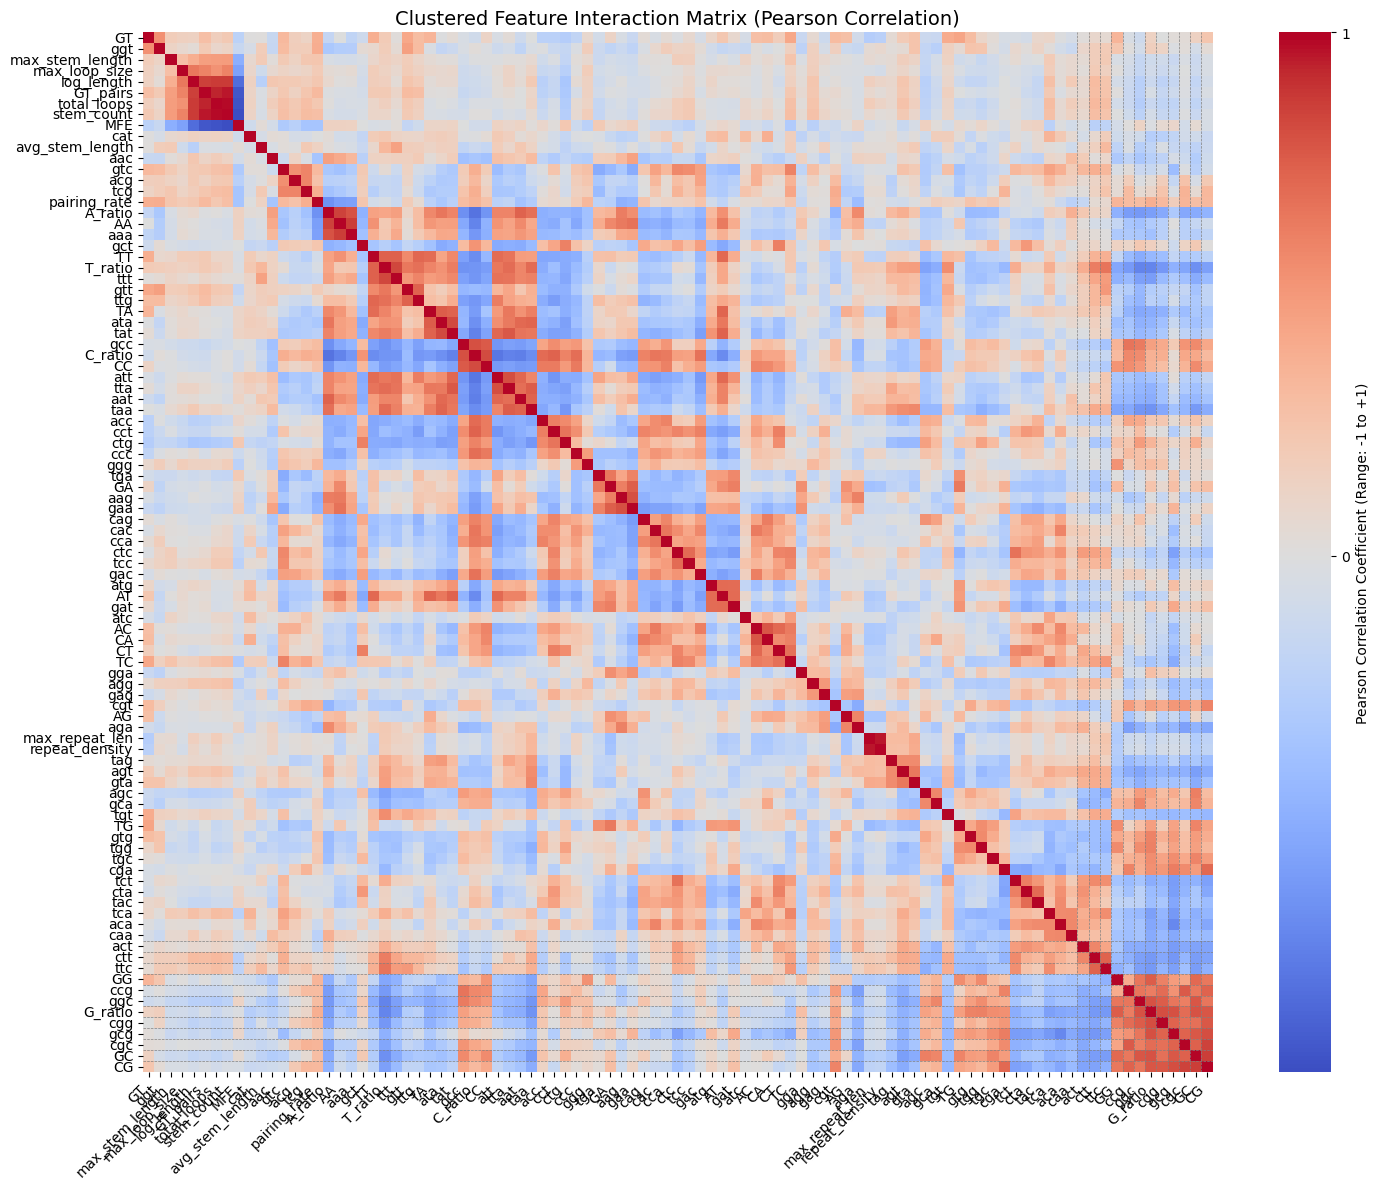

In [34]:
import scipy.cluster.hierarchy as sch
import numpy as np

# Calculate the Pearson correlation coefficient matrix
corr_matrix = all_features.corr()

# 1. Hierarchical clustering (based on correlation distance)
# Using 1 - |correlation coefficient| as the distance metric (higher correlation = shorter distance)
distance_matrix = 1 - np.abs(corr_matrix.values)
linkage = sch.linkage(sch.distance.squareform(distance_matrix), method='average')

# Get the clustered feature order
clustered_order = sch.dendrogram(linkage, no_plot=True)['leaves']
clustered_features = corr_matrix.columns[clustered_order]

# 2. Reorder the correlation coefficient matrix according to clustering results
clustered_corr = corr_matrix.iloc[clustered_order, clustered_order]

# 3. Plot the heatmap (with clustering)
plt.figure(figsize=(15, 12))

heatmap = sns.heatmap(
    clustered_corr,
    annot=False,
    cmap='coolwarm',
    center=0,
    xticklabels=clustered_features,
    yticklabels=clustered_features,
    cbar_kws={
        'ticks': [1, 0, -1],
        'label': 'Pearson Correlation Coefficient (Range: -1 to +1)'
    }
)

# Add dashed lines to indicate clustering groups (optional)
for i in range(1, len(clustered_order)):
    if linkage[i-1, 2] > 0.7:  # Adjust threshold based on the actual dendrogram height
        plt.axhline(y=i, color='gray', linestyle='--', linewidth=0.5)
        plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.5)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Clustered Feature Interaction Matrix (Pearson Correlation)', fontsize=14)
plt.tight_layout()

save_path = r'features_heatmap_clustered.png'
plt.savefig(save_path, format='png', dpi=600, bbox_inches='tight')
plt.show()

## 3. Machine Learning Models
#### 3.1 Feature Matrix Construction and Standardization
The extracted DNA sequence features, including primary structure features (nucleotide composition, dinucleotide frequencies, 3-mer frequencies, repeat sequence characteristics) and secondary structure features (MFE, maximum stem length, average stem length, total loops, maximum loop size, GT wobble pairs, pairing rate), were integrated to construct a feature matrix. Each row of the feature matrix represents a DNA sequence, and each column represents a feature.

The constructed feature matrix was used as the independent variable X, with synthesis duration as the dependent variable y. Data preprocessing was performed, including handling missing values (using median imputation per feature) and standardization (scaling the data to a distribution with mean of 0 and standard deviation of 1).

In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_reg = all_features.copy()
y_reg = df['Duration']

# Remove features with zero variance (all values are zero)
X_reg = X_reg.apply(pd.to_numeric, errors='coerce')
zero_features_reg = np.all(X_reg == 0, axis=0)
X_reg = X_reg.loc[:, ~zero_features_reg]

# Handle missing values
for col in X_reg.columns:
    if X_reg[col].dtype in [np.float64, np.int64]:
        X_reg[col].fillna(X_reg[col].median(), inplace=True)

# Standardize the features
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
X_reg_scaled

array([[-0.99262126, -0.61286453, -0.01582083, ..., -0.4307169 ,
        -0.6827742 ,  0.64998937],
       [-0.84244015, -1.08588532,  0.08915057, ...,  0.86759078,
        -0.67152794,  0.55162471],
       [-0.90694106, -0.76560549, -0.37182743, ..., -0.22198397,
        -0.62654291,  0.65707871],
       ...,
       [-0.11577909, -0.11922418,  0.58019864, ...,  0.10692663,
        -0.33414022,  0.28422348],
       [-0.11577909, -0.16280373,  0.55417077, ...,  0.50443966,
        -0.27790893,  0.28776815],
       [-0.72990326, -0.50814636,  1.35180388, ...,  0.7920093 ,
        -0.57031163,  0.56779728]])

#### 3.2 Regression Model Construction
In this study, to build regression models for predicting DNA synthesis difficulty, we selected five regression models for training: XGBoost, Random Forest, Gradient Boosting, Support Vector Regression (SVR), and Lasso Regression.

##### XGBoost Regression Model
- XGBoost is an efficient gradient boosting framework that excels at handling large numbers of features and complex nonlinear relationships, demonstrating strong performance in both prediction accuracy and model stability. When dealing with complex bioinformatics data such as gene synthesis difficulty prediction, XGBoost can effectively capture complex interactions between features, promising high-precision prediction results. Additionally, XGBoost provides feature importance scores, helping us understand which features are most critical for predicting gene synthesis difficulty. The model also supports custom loss functions, allowing flexible adjustments based on the specific requirements of gene synthesis difficulty prediction.

##### Random Forest Regression Model
- Random Forest is an ensemble learning method that improves model accuracy and stability by constructing multiple decision trees and aggregating their predictions. For gene difficulty prediction, Random Forest can handle high-dimensional feature data and is robust to outliers and noise. Furthermore, Random Forest provides feature importance information, helping us identify key features that influence gene synthesis difficulty.

##### Gradient Boosting Regression Model
- Gradient Boosting is a powerful ensemble learning technique that improves prediction performance by progressively building a series of models, each correcting the errors of its predecessor. In the task of gene synthesis difficulty prediction, Gradient Boosting can effectively utilize feature information and progressively optimize the model's predictive capability. Its iterative optimization characteristics enable it to effectively fit complex patterns in the data.

##### Support Vector Regression (SVR) Model
- Support Vector Regression is a regression method based on Support Vector Machine (SVM) theory, which finds a hyperplane that predicts the target value with minimal error. SVR has unique advantages in handling small samples, nonlinearity, and high-dimensional data, making it well-suited for bioinformatics problems such as gene synthesis difficulty prediction, especially when the feature space is complex and the sample size is relatively limited.

##### Lasso Regression Model
- Lasso Regression is a linear regression method with L1 regularization that performs feature selection and model compression. In gene synthesis difficulty prediction research, we face a large number of features (such as nucleotide composition, dinucleotide frequencies, k-mer frequencies, etc.). Lasso Regression helps us select the features that contribute most to prediction, thereby simplifying the model and improving prediction efficiency.

In [36]:
# Inspect the source DataFrame you used to create X_reg and y_reg
print("Original df shape:", df.shape)
print("Original df columns:", df.columns.tolist())
print("First 5 rows of df:")
print(df.head())

# Inspect the target vector
print("y_reg length:", len(y_reg))
print("y_reg sample:", y_reg[:5])


Original df shape: (1593, 23)
Original df columns: ['ID', 'Sequence', 'Length', 'Duration', 'vienna', 'MFE', 'max_stem_length', 'avg_stem_length', 'total_loops', 'max_loop_size', 'GT_pairs', 'pairing_rate', 'stem_count', 'length', 'sqrt_length', 'length_ratio', 'length_category', 'length_zscore', 'A_ratio', 'G_ratio', 'C_ratio', 'T_ratio', 'Clean_Sequence']
First 5 rows of df:
   ID                                           Sequence  Length  Duration  \
0   1  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     417         5   
1   2  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     471         5   
2   3  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     447         5   
3   4  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     417         5   
4   5  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     420         5   

                                              vienna    MFE  max_stem_length  \
0  .(((((((((....((.(((.((((((((....))))))))....)... -148.8            

In [37]:
print("df shape:", df.shape)
print("df file preview:")
print(df.head())

print("y_reg length:", len(y_reg))
print("X_reg_scaled shape:", X_reg_scaled.shape)


df shape: (1593, 23)
df file preview:
   ID                                           Sequence  Length  Duration  \
0   1  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     417         5   
1   2  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     471         5   
2   3  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     447         5   
3   4  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     417         5   
4   5  tctagagccaccATGTACAGAATGCAGCTGCTGAGCTGCATCGCCC...     420         5   

                                              vienna    MFE  max_stem_length  \
0  .(((((((((....((.(((.((((((((....))))))))....)... -148.8                9   
1  ......(((((((.((.....((((((((....))))))))(((((... -193.2                9   
2  (((((.(((.(((.((.(((.((((((((....))))))))....)... -145.6                8   
3  ..((((((((....((.(((.((((((((....))))))))....)... -180.3               12   
4  .......((((((.((.(((.((((((((....))))))))....)... -161.5                9   

   avg_stem_

In [38]:
import pandas as pd

# Build regression_data from the current dataset
regression_data = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)
regression_data['Duration'] = y_reg.values

# Save to CSV
regression_data.to_csv('regression_data.csv', index=False)

# Reload to confirm
regression_data = pd.read_csv('regression_data.csv')
print("Regression dataset shape:", regression_data.shape)
print("\nFirst 5 rows of the regression dataset:")
print(regression_data.head())

Regression dataset shape: (1593, 96)

First 5 rows of the regression dataset:
   log_length   A_ratio   G_ratio   C_ratio   T_ratio        AA        AG  \
0   -0.992621 -0.612865 -0.015821  1.431894 -1.044746 -0.874494  0.357945   
1   -0.842440 -1.085885  0.089151  1.487144 -0.674723 -1.221933  0.201834   
2   -0.906941 -0.765605 -0.371827  1.481281 -0.592921 -0.778980  0.516106   
3   -0.992621 -1.189588  0.514099  1.349673 -0.792604 -1.207299  0.641236   
4   -0.983780 -0.906613  0.204096  1.514701 -1.021693 -0.935919  0.473222   

         AC        AT        GA  ...  repeat_density  max_stem_length  \
0  1.684665 -0.774467  0.079595  ...       -0.178873        -0.419806   
1  1.681708 -1.037848 -0.379580  ...       -0.169747        -0.419806   
2  1.006062 -0.882449 -0.234368  ...       -0.174219        -0.562488   
3  0.989860 -1.131207 -0.138177  ...       -0.178873         0.008240   
4  1.515856 -1.228693 -0.051120  ...       -0.175465        -0.419806   

   avg_stem_length  

#### 3.3 Regression Model Cross-Validation (K-Fold = 5)
To ensure high accuracy and reliability in evaluating the performance of the regression models, we employed 5-fold cross-validation for all regression models. In 5-fold cross-validation, the original dataset is randomly divided into 5 equal-sized subsets. Each subset serves as the test set in turn during the validation process, while the union of the remaining 4 subsets serves as the training set. The model is trained on each training set and evaluated on the corresponding test set. Finally, the model's performance metrics (such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²)) are averaged across the 5 validation results. This validation approach maximizes the use of available data for model training and evaluation under limited data resources, reducing bias caused by data partitioning. Through 5-fold cross-validation, we can more accurately estimate the model's generalization ability in real-world applications, ensuring that the selected regression model maintains stable and reliable predictive performance across different data subsets.

In [39]:
imputer = SimpleImputer(strategy='mean')

# Try to import XGBoost; if it fails, fall back to RandomForest and continue
try:
    from xgboost import XGBRegressor
    xgb_available = True
    print("XGBoost import succeeded.")
except Exception as e:
    print("XGBoost import failed:", e)
    XGBRegressor = None
    xgb_available = False
    print("Falling back to RandomForest for the XGBoost slot.")

# Define model factory for the XGBoost slot (either real XGB or RF fallback)
def make_xgb_like():
    if xgb_available:
        return XGBRegressor(
            n_estimators=150,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42
        )
    else:
        # RandomForest fallback with similar complexity
        return RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='log2',
            bootstrap=True,
            random_state=42
        )

# 5 regression models (XGBoost slot uses fallback if needed)
reg_models = {
    "XGBoost": make_xgb_like(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='log2',
        bootstrap=True,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        min_samples_split=5,
        max_features='sqrt',
        random_state=42
    ),
    "SVR (RBF)": SVR(
        kernel='rbf',
        C=0.5,
        gamma='scale',
        epsilon=0.1
    ),
    "Lasso Regression": Lasso(
        alpha=0.05,
        selection='cyclic',
        max_iter=10000,
        random_state=42
    )
}


XGBoost import succeeded.


In [40]:
### Cross-Validation Evaluation 
X_reg_scaled = regression_data.drop(['Duration'], axis=1)
y_reg = regression_data['Duration']

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['r2', 'neg_root_mean_squared_error']

results = {}
for name, model in reg_models.items():
    pipeline = Pipeline([
        ('imputer', imputer),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    cv_results = cross_validate(
        pipeline, X_reg_scaled, y_reg, 
        cv=kfold,
        scoring=metrics,
        return_train_score=False,
        n_jobs=-1,
        error_score='raise'
    )
    
    results[name] = {
        'R2_mean': cv_results['test_r2'].mean(),
        'R2_std': cv_results['test_r2'].std(),
        'RMSE_mean': -cv_results['test_neg_root_mean_squared_error'].mean(),
        'RMSE_std': cv_results['test_neg_root_mean_squared_error'].std()
    }

#### 3.4 Regression Model Performance Evaluation
In this study, we evaluated model performance using two metrics: R² score and Root Mean Squared Error (RMSE). The R² score measures the goodness of fit of the model to the data, with a range of [0, 1]—values closer to 1 indicate better fit. RMSE measures the difference between predicted and actual values—smaller values indicate better performance.

After 5-fold cross-validation, XGBoost, Random Forest, and Gradient Boosting all demonstrated excellent predictive performance and good stability, with average R² values of 0.8519, 0.8390, and 0.8444, respectively, and average RMSE values of 5.32, 5.52, and 5.44, respectively. Overall, Random Forest achieved the best performance and was therefore selected as the optimal regression model for predicting DNA synthesis difficulty.

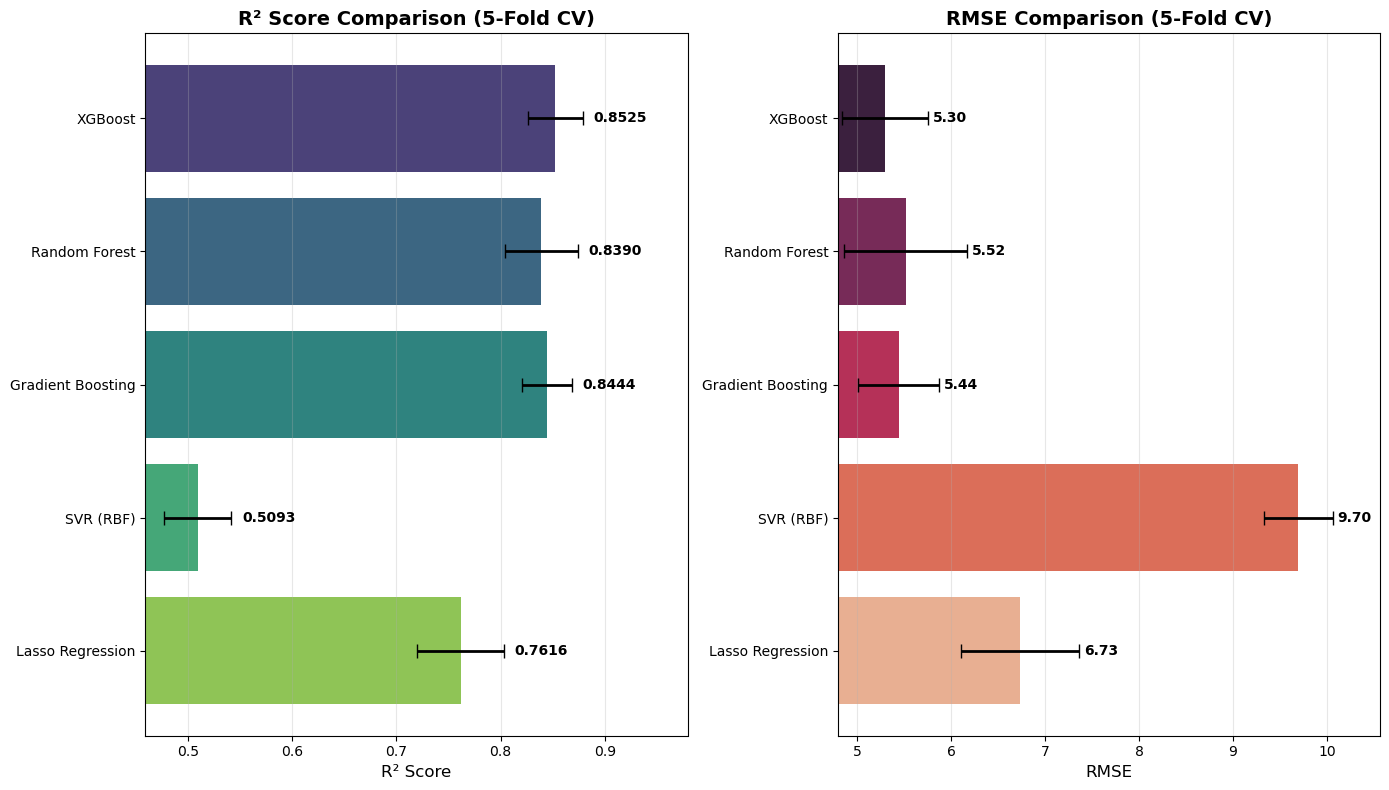


Cross-model performance comparison:
                    R2_mean  RMSE_mean
XGBoost            0.852481   5.295531
Gradient Boosting  0.844368   5.441631
Random Forest      0.839042   5.515399
Lasso Regression   0.761558   6.734750
SVR (RBF)          0.509324   9.695464


In [41]:
# Model performance comparison
plt.figure(figsize=(14, 8))

# R² score comparison
plt.subplot(1, 2, 1)
ax = sns.barplot(
    x=[results[name]['R2_mean'] for name in reg_models],
    y=list(reg_models.keys()),
    palette="viridis"
)

# Add error bars
for i, name in enumerate(reg_models.keys()):
    mean = results[name]['R2_mean']
    std  = results[name]['R2_std']
    ax.errorbar(mean, i, xerr=std, fmt='none', c='black', capsize=5, linewidth=2)

# Add mean value labels - positioned at the end of the error bar
for i, (name, v) in enumerate(zip(reg_models.keys(), [results[name]['R2_mean'] for name in reg_models])):
    std = results[name]['R2_std']
    # Position at the end of the error bar (mean + std + small padding)
    label_pos = v + std + 0.01
    ax.text(label_pos, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.title('R² Score Comparison (5-Fold CV)', fontsize=14, fontweight='bold')
plt.xlabel('R² Score', fontsize=12)
# Auto-adjust xlim to accommodate labels
max_val = max([results[name]['R2_mean'] + results[name]['R2_std'] for name in reg_models])
plt.xlim(min([results[name]['R2_mean'] for name in reg_models]) - 0.05, max_val + 0.1)
plt.grid(True, alpha=0.3, axis='x')

# RMSE comparison
plt.subplot(1, 2, 2)
ax = sns.barplot(
    x=[results[name]['RMSE_mean'] for name in reg_models],
    y=list(reg_models.keys()),
    palette="rocket"
)

for i, name in enumerate(reg_models.keys()):
    mean = results[name]['RMSE_mean']
    std  = results[name]['RMSE_std']
    ax.errorbar(mean, i, xerr=std, fmt='none', c='black', capsize=5, linewidth=2)

# Add mean value labels - positioned at the end of the error bar
for i, (name, v) in enumerate(zip(reg_models.keys(), [results[name]['RMSE_mean'] for name in reg_models])):
    std = results[name]['RMSE_std']
    # Position at the end of the error bar (mean + std + small padding)
    label_pos = v + std + 0.05
    ax.text(label_pos, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('RMSE Comparison (5-Fold CV)', fontsize=14, fontweight='bold')
plt.xlabel('RMSE', fontsize=12)
# Auto-adjust xlim to accommodate labels
max_val = max([results[name]['RMSE_mean'] + results[name]['RMSE_std'] for name in reg_models])
plt.xlim(min([results[name]['RMSE_mean'] for name in reg_models]) - 0.5, max_val + 0.5)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('Regression_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Overall results output ###
results_df = pd.DataFrame(results).T
print("\nCross-model performance comparison:")
print(results_df[['R2_mean', 'RMSE_mean']].sort_values('R2_mean', ascending=False))

#### 3.4 Model fine tuning (XGBoost)

XGBOOST HYPERPARAMETER OPTIMIZATION

STRATIFIED TRAIN/VALIDATION SPLIT
✓ Using 5 quantile bins

📊 Data split (70/30):
   Training: 1115 samples (70.0%)
   Validation: 478 samples (30.0%)
   Features: 95

📊 Training Duration stats:
   Mean: 12.70, Std: 13.96
   Min: 2.00, Max: 69.00

📊 Validation Duration stats:
   Mean: 12.59, Std: 13.65
   Min: 2.00, Max: 69.00

📊 Data split:
   Training: 1115 samples
   Validation: 478 samples
   Features: 95

🔍 Starting hyperparameter optimization...
   Searching 16 parameter combinations
   Number of iterations: 100
   Cross-validation folds: 5
   Scoring: R²
Fitting 5 folds for each of 100 candidates, totalling 500 fits

OPTIMIZATION RESULTS

🏆 Best Parameters Found:
   model__subsample: 0.7
   model__skip_drop: 0.1
   model__sample_type: uniform
   model__reg_lambda: 0.01
   model__reg_alpha: 5.0
   model__rate_drop: 0.1
   model__normalize_type: tree
   model__n_estimators: 1000
   model__min_child_weight: 6
   model__max_depth: 12
   model__lea

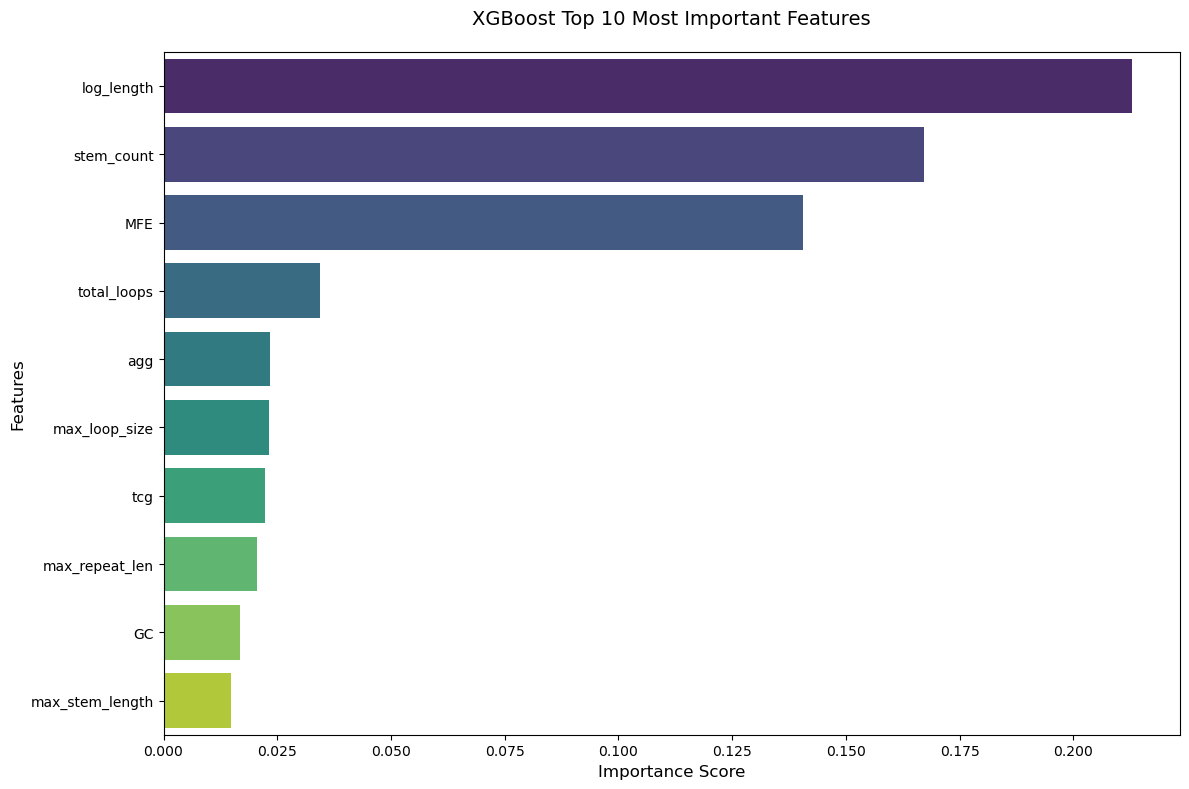


SHAP ANALYSIS

🔍 Extracting model and preparing data for SHAP...
   Model type: <class 'xgboost.sklearn.XGBRegressor'>
   Processed data shape: (478, 95)

🔮 Creating SHAP explainer with TreeExplainer...
✓ TreeExplainer with booster successful

📊 SHAP values shape: (478, 95)
   Feature matrix shape: (478, 95)

📊 Generating SHAP plots...


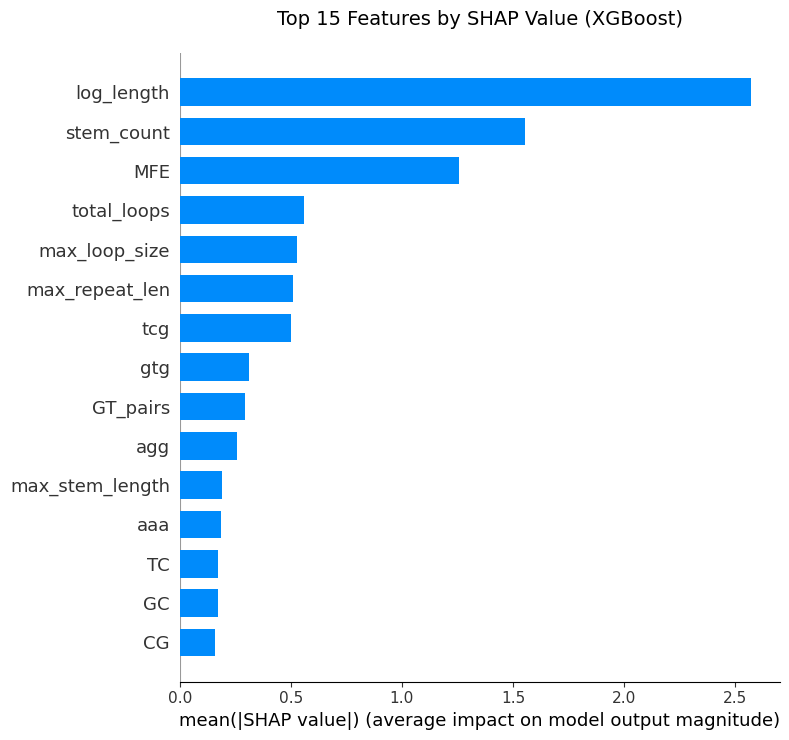

✅ SHAP feature importance plot saved


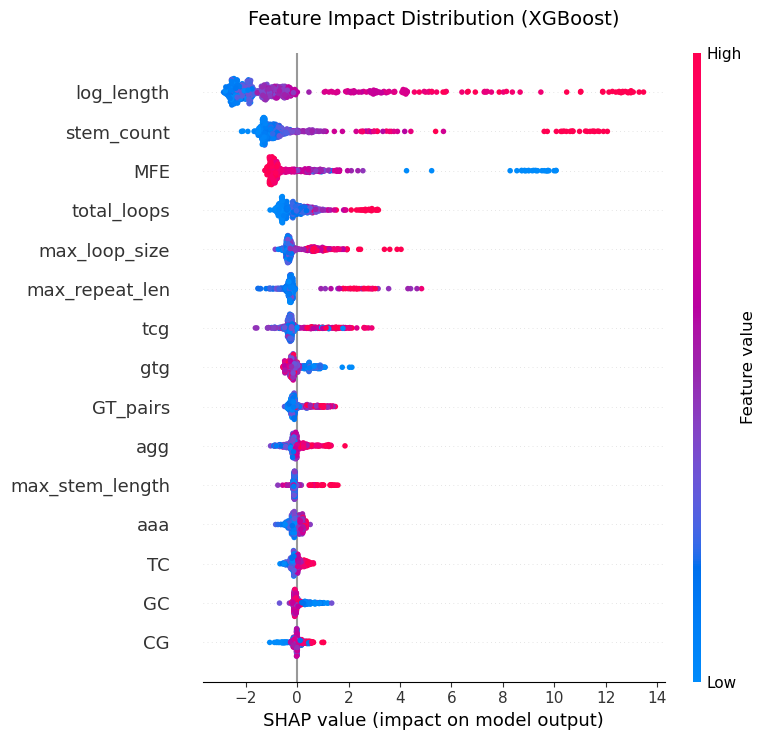

✅ SHAP feature impact distribution plot saved


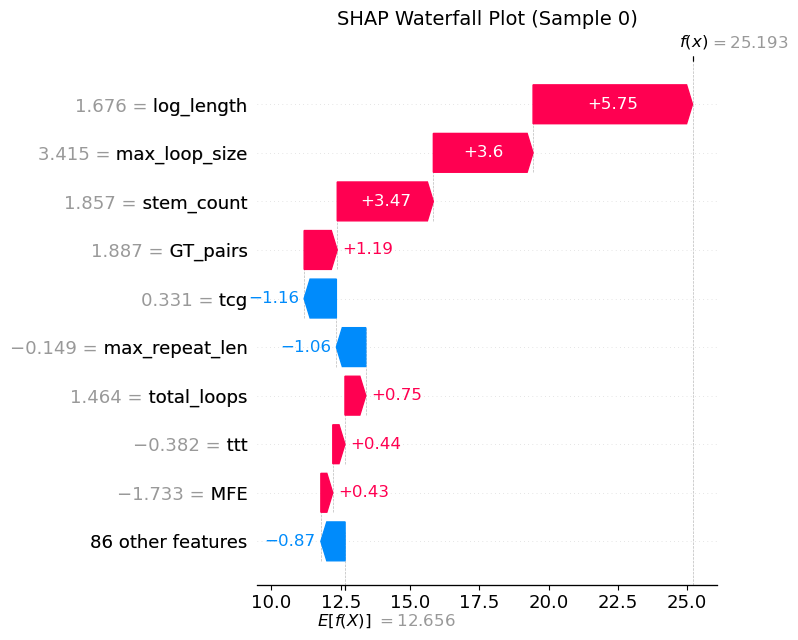

✅ SHAP waterfall plot saved

📊 Generating SHAP dependence plots for: ['log_length', 'stem_count', 'MFE']


<Figure size 1000x600 with 0 Axes>

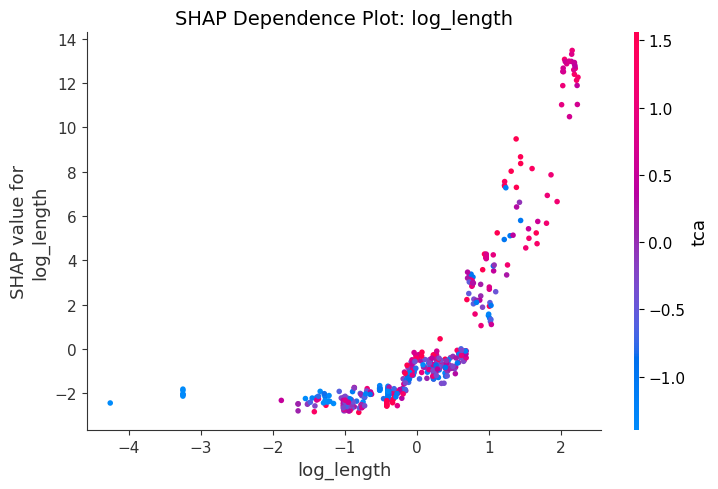

   ✓ Dependence plot saved for log_length


<Figure size 1000x600 with 0 Axes>

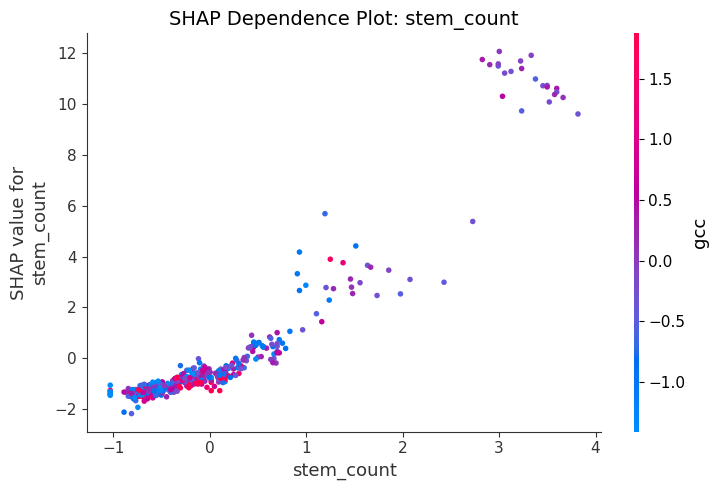

   ✓ Dependence plot saved for stem_count


<Figure size 1000x600 with 0 Axes>

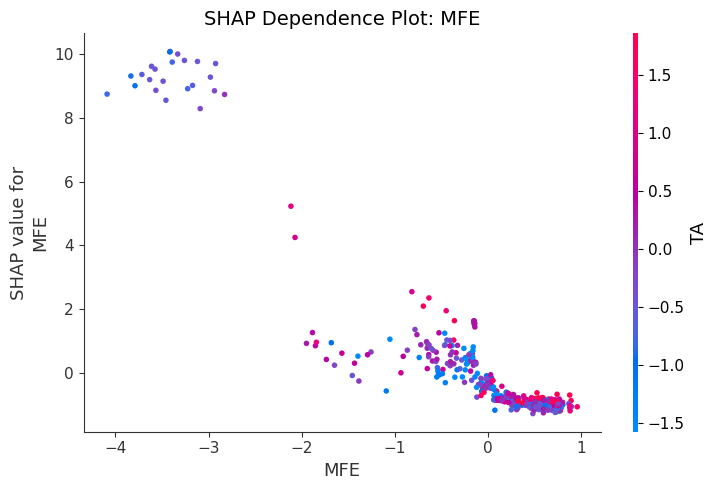

   ✓ Dependence plot saved for MFE

📊 SHAP Importance Summary:
           Feature  SHAP_Importance
0       log_length         2.573025
93      stem_count         1.554716
94             MFE         1.258801
89     total_loops         0.559255
90   max_loop_size         0.525713
85  max_repeat_len         0.509027
75             tcg         0.499014
67             gtg         0.313127
91        GT_pairs         0.292618
31             agg         0.257460
✓ SHAP importance saved to 'shap_importance.csv'

SHAP ANALYSIS COMPLETE

✓ Best XGBoost model saved to 'xgboost_best_model.pkl'
✓ Optimization results saved to 'xgboost_optimization_results.csv'

XGBOOST OPTIMIZATION COMPLETE!

💡 Recommendations:
   ✅ Excellent model performance (R² > 0.8)

📊 Best Parameters Summary:
   n_estimators: 1000
   max_depth: 12
   learning_rate: 0.07
   subsample: 0.7
   colsample_bytree: 0.5
   reg_alpha: 5.0
   reg_lambda: 0.01
   min_child_weight: 6


In [42]:
warnings.filterwarnings('ignore')

# ============================================================================
# XGBOOST HYPERPARAMETER OPTIMIZATION
# ============================================================================

print("=" * 70)
print("XGBOOST HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

# Prepare data
X = regression_data.drop(['Duration'], axis=1)
y = regression_data['Duration']

# ============================================================================
# PROPER STRATIFIED SPLIT (USING ALREADY SHUFFLED DATA)
# ============================================================================

print("\n" + "=" * 70)
print("STRATIFIED TRAIN/VALIDATION SPLIT")
print("=" * 70)

# Create bins for stratification based on target
n_bins = min(5, len(y) // 10)
try:
    y_bins = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
    print(f"✓ Using {len(np.unique(y_bins))} quantile bins")
except:
    y_bins = pd.cut(y, bins=5, labels=False)
    print("✓ Using 5 equal-width bins")

# Perform stratified split WITHOUT re-shuffling
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, val_idx = next(sss.split(X, y_bins))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_val = X.iloc[val_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_val = y.iloc[val_idx].reset_index(drop=True)

print(f"\n📊 Data split (70/30):")
print(f"   Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Features: {X_train.shape[1]}")

print(f"\n📊 Training Duration stats:")
print(f"   Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"   Min: {y_train.min():.2f}, Max: {y_train.max():.2f}")

print(f"\n📊 Validation Duration stats:")
print(f"   Mean: {y_val.mean():.2f}, Std: {y_val.std():.2f}")
print(f"   Min: {y_val.min():.2f}, Max: {y_val.max():.2f}")

print(f"\n📊 Data split:")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Validation: {X_val.shape[0]} samples")
print(f"   Features: {X_train.shape[1]}")

# ============================================================================
# 1. CREATE PIPELINE WITH XGBOOST
# ============================================================================

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1,
        verbosity=0
    ))
])

# ============================================================================
# 2. DEFINED OPTIMIZED PARAMETER DISTRIBUTION FOR XGBOOST
# ============================================================================

param_dist = {
    'model__n_estimators': np.arange(100, 1001, 100),
    'model__max_depth': np.arange(3, 13, 1),
    'model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
    'model__subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bylevel': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bynode': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    'model__reg_lambda': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    'model__min_child_weight': np.arange(1, 11, 1),
    'model__gamma': [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    'model__booster': ['gbtree', 'dart'],
    'model__sample_type': ['uniform', 'weighted'],
    'model__normalize_type': ['tree', 'forest'],
    'model__rate_drop': [0.0, 0.01, 0.05, 0.1, 0.2, 0.3],
    'model__skip_drop': [0.0, 0.1, 0.3, 0.5, 0.7],
}

# ============================================================================
# 3. PERFORM RANDOMIZED SEARCH WITH CROSS-VALIDATION
# ============================================================================

print("\n🔍 Starting hyperparameter optimization...")
print(f"   Searching {len(param_dist)} parameter combinations")
print(f"   Number of iterations: 100")
print(f"   Cross-validation folds: 5")
print(f"   Scoring: R²")

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=100,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the random search
random_search.fit(X_train, y_train)

# ============================================================================
# 4. RESULTS AND EVALUATION
# ============================================================================

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)

print("\n🏆 Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation R² Score: {random_search.best_score_:.4f}")

# ============================================================================
# 5. EVALUATE ON VALIDATION SET
# ============================================================================

# Best model
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_val)

# Calculate metrics
val_r2 = r2_score(y_val, y_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
val_mae = mean_absolute_error(y_val, y_pred)
val_mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100

print("\n📊 Validation Set Performance:")
print(f"   R² Score: {val_r2:.4f}")
print(f"   RMSE: {val_rmse:.4f}")
print(f"   MAE: {val_mae:.4f}")
print(f"   MAPE: {val_mape:.2f}%")

# ============================================================================
# 6. COMPARE WITH DEFAULT XGBOOST
# ============================================================================

print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)

original_model = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1,
        verbosity=0
    ))
])
original_model.fit(X_train, y_train)
original_pred = original_model.predict(X_val)

original_r2 = r2_score(y_val, original_pred)
original_rmse = np.sqrt(mean_squared_error(y_val, original_pred))
original_mae = mean_absolute_error(y_val, original_pred)

print("\n📊 Model Comparison:")
print(f"{'Metric':<15} {'Default XGBoost':<20} {'Tuned XGBoost':<20} {'Improvement':<15}")
print("-" * 70)
print(f"{'R²':<15} {original_r2:<20.4f} {val_r2:<20.4f} {val_r2 - original_r2:<15.4f}")
print(f"{'RMSE':<15} {original_rmse:<20.4f} {val_rmse:<20.4f} {original_rmse - val_rmse:<15.4f}")
print(f"{'MAE':<15} {original_mae:<20.4f} {val_mae:<20.4f} {original_mae - val_mae:<15.4f}")

print(f"\n📈 R² Improvement: {(val_r2 - original_r2) * 100:.2f}%")
print(f"📉 RMSE Reduction: {(original_rmse - val_rmse) / original_rmse * 100:.2f}%")

# ============================================================================
# 7. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

if val_r2 > original_r2:
    print("\n" + "=" * 70)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 70)
    
    feature_importances = best_xgb.named_steps['model'].feature_importances_
    features = X.columns
    
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Top 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))
    
    importance_df.to_csv('xgb_feature_importance.csv', index=False)
    print("\n✓ Feature importance saved to 'xgb_feature_importance.csv'")
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(10)
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title('XGBoost Top 10 Most Important Features', fontsize=14, pad=20)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.savefig('xgb_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# 8. SHAP ANALYSIS (USING YOUR ORIGINAL APPROACH)
# ============================================================================

print("\n" + "=" * 70)
print("SHAP ANALYSIS")
print("=" * 70)

try:
    import shap
    import xgboost as xgb
    
    # ✅ APPROACH 1: Extract the model and preprocess data manually
    print("\n🔍 Extracting model and preparing data for SHAP...")
    
    # Get the raw XGBoost model from pipeline
    xgb_model_raw = best_xgb.named_steps['model']
    
    # Get the preprocessor from pipeline
    imputer = best_xgb.named_steps['imputer']
    scaler = best_xgb.named_steps['scaler']
    
    # Preprocess the validation data the same way
    X_val_processed = scaler.transform(imputer.transform(X_val))
    
    print(f"   Model type: {type(xgb_model_raw)}")
    print(f"   Processed data shape: {X_val_processed.shape}")
    
    # ✅ METHOD 1: TreeExplainer with booster (like your original code)
    try:
        print("\n🔮 Creating SHAP explainer with TreeExplainer...")
        
        # Get booster
        booster = xgb_model_raw.get_booster()
        
        # Create explainer using booster
        explainer_reg = shap.TreeExplainer(
            booster,
            model_output="raw",
            feature_perturbation="interventional"
        )
        shap_values_reg = explainer_reg.shap_values(X_val_processed)
        print("✓ TreeExplainer with booster successful")
        
    except Exception as e:
        print(f"TreeExplainer failed: {e}")
        print("Trying KernelExplainer as fallback...")
        
        # ✅ METHOD 2: KernelExplainer (fallback)
        # Use a subset of data as background
        background = shap.sample(X_val_processed, 100)
        
        # Create a predict function
        def predict_fn(X):
            return xgb_model_raw.predict(X)
        
        # KernelExplainer
        explainer_reg = shap.KernelExplainer(
            predict_fn,
            background
        )
        
        # Get SHAP values for all data
        shap_values_reg = explainer_reg.shap_values(X_val_processed)
        print("✓ KernelExplainer successful")
    
    # Verify SHAP values
    print(f"\n📊 SHAP values shape: {shap_values_reg.shape}")
    print(f"   Feature matrix shape: {X_val_processed.shape}")
    
    if shap_values_reg.shape != X_val_processed.shape:
        print(f"⚠️ Shape mismatch! Attempting to fix...")
        if shap_values_reg.shape[0] == X_val_processed.shape[1] and shap_values_reg.shape[1] == X_val_processed.shape[0]:
            shap_values_reg = shap_values_reg.T
            print(f"Fixed shape: {shap_values_reg.shape}")
    
    # Generate SHAP feature importance bar plot
    print("\n📊 Generating SHAP plots...")
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_reg,
        X_val_processed,
        feature_names=X.columns.tolist(),
        plot_type="bar",
        max_display=15,
        show=False
    )
    plt.title("Top 15 Features by SHAP Value (XGBoost)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig('XGboost_shap_regression_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print("✅ SHAP feature importance plot saved")
    
    # Generate SHAP feature impact distribution plot (beeswarm)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_reg,
        X_val_processed,
        feature_names=X.columns.tolist(),
        max_display=15,
        show=False
    )
    plt.title("Feature Impact Distribution (XGBoost)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig('XGboost_Feature_Impact_Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print("✅ SHAP feature impact distribution plot saved")
    
    # Additional: SHAP waterfall plot for a single prediction
    try:
        sample_idx = 0
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_reg[sample_idx],
                base_values=explainer_reg.expected_value,
                data=X_val_processed[sample_idx],
                feature_names=X.columns.tolist()
            ),
            max_display=10,
            show=False
        )
        plt.title(f"SHAP Waterfall Plot (Sample {sample_idx})", fontsize=14)
        plt.tight_layout()
        plt.savefig('XGboost_shap_waterfall_sample.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print("✅ SHAP waterfall plot saved")
    except Exception as e:
        print(f"⚠️ Could not create waterfall plot: {e}")
    
    # SHAP dependence plots for top features
    try:
        top_3_features = importance_df.head(3)['Feature'].tolist()
        print(f"\n📊 Generating SHAP dependence plots for: {top_3_features}")
        
        for feature in top_3_features:
            plt.figure(figsize=(10, 6))
            shap.dependence_plot(
                feature,
                shap_values_reg,
                X_val_processed,
                feature_names=X.columns.tolist(),
                show=False
            )
            plt.title(f'SHAP Dependence Plot: {feature}', fontsize=14)
            plt.tight_layout()
            plt.savefig(f'XGboost_shap_dependence_{feature}.png', dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()
            print(f"   ✓ Dependence plot saved for {feature}")
    except Exception as e:
        print(f"⚠️ Could not create dependence plots: {e}")
    
    # SHAP summary statistics
    shap_importance = pd.DataFrame({
        'Feature': X.columns.tolist(),
        'SHAP_Importance': np.abs(shap_values_reg).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    
    print("\n📊 SHAP Importance Summary:")
    print(shap_importance.head(10))
    shap_importance.to_csv('shap_importance.csv', index=False)
    print("✓ SHAP importance saved to 'shap_importance.csv'")
    
    print("\n" + "=" * 70)
    print("SHAP ANALYSIS COMPLETE")
    print("=" * 70)
    
except ImportError:
    print("⚠️ SHAP not installed. Skipping SHAP analysis.")
    print("   Install with: pip install shap")
except Exception as e:
    print(f"⚠️ SHAP analysis failed: {e}")
    print("   Debugging tips:")
    print("   1. Make sure SHAP is installed: pip install shap")
    print("   2. Check XGBoost version compatibility")
    print("   3. Try using KernelExplainer instead")

# ============================================================================
# 9. SAVE THE BEST MODEL
# ============================================================================

import joblib

# Save the best model
joblib.dump(best_xgb, 'xgboost_best_model.pkl')
print(f"\n✓ Best XGBoost model saved to 'xgboost_best_model.pkl'")

# Save the random search results
results_df = pd.DataFrame(random_search.cv_results_)
results_df.to_csv('xgboost_optimization_results.csv', index=False)
print(f"✓ Optimization results saved to 'xgboost_optimization_results.csv'")

print("\n" + "=" * 70)
print("XGBOOST OPTIMIZATION COMPLETE!")
print("=" * 70)

# ============================================================================
# 10. RECOMMENDATIONS
# ============================================================================

print("\n💡 Recommendations:")
if val_r2 > 0.8:
    print("   ✅ Excellent model performance (R² > 0.8)")
elif val_r2 > 0.6:
    print("   ✅ Good model performance (R² > 0.6)")
elif val_r2 > 0.4:
    print("   ⚠️ Moderate model performance (R² > 0.4)")
    print("   Consider:")
    print("   - Adding more features")
    print("   - Collecting more data")
    print("   - Trying feature engineering")
else:
    print("   ⚠️ Model performance needs improvement")
    print("   Consider:")
    print("   - Feature engineering")
    print("   - Adding more training data")
    print("   - Trying different algorithms")

print("\n📊 Best Parameters Summary:")
best_params = random_search.best_params_
print(f"   n_estimators: {best_params.get('model__n_estimators', 'N/A')}")
print(f"   max_depth: {best_params.get('model__max_depth', 'N/A')}")
print(f"   learning_rate: {best_params.get('model__learning_rate', 'N/A')}")
print(f"   subsample: {best_params.get('model__subsample', 'N/A')}")
print(f"   colsample_bytree: {best_params.get('model__colsample_bytree', 'N/A')}")
print(f"   reg_alpha: {best_params.get('model__reg_alpha', 'N/A')}")
print(f"   reg_lambda: {best_params.get('model__reg_lambda', 'N/A')}")
print(f"   min_child_weight: {best_params.get('model__min_child_weight', 'N/A')}")

#### 3.5 Secondary-Structure Ablation Analysis

SECONDARY-STRUCTURE ABLATION ANALYSIS
Total features: 95
Primary-sequence features: 87
Secondary-structure features: 8

Using optimized XGBoost parameters:
  subsample: 0.7
  skip_drop: 0.1
  sample_type: uniform
  reg_lambda: 0.01
  reg_alpha: 5.0
  rate_drop: 0.1
  normalize_type: tree
  n_estimators: 1000
  min_child_weight: 6
  max_depth: 12
  learning_rate: 0.07
  gamma: 0.2
  colsample_bytree: 0.5
  colsample_bynode: 0.6
  colsample_bylevel: 1.0
  booster: gbtree
  random_state: 42
  objective: reg:squarederror
  n_jobs: -1
  verbosity: 0

----------------------------------------------------------------------
Feature set: Length only
Number of features: 1
R²   = 0.7505
RMSE = 6.8116 days
MAE  = 3.8068 days

----------------------------------------------------------------------
Feature set: Primary sequence
Number of features: 87
R²   = 0.8311
RMSE = 5.6032 days
MAE  = 3.0929 days

----------------------------------------------------------------------
Feature set: Primary + second

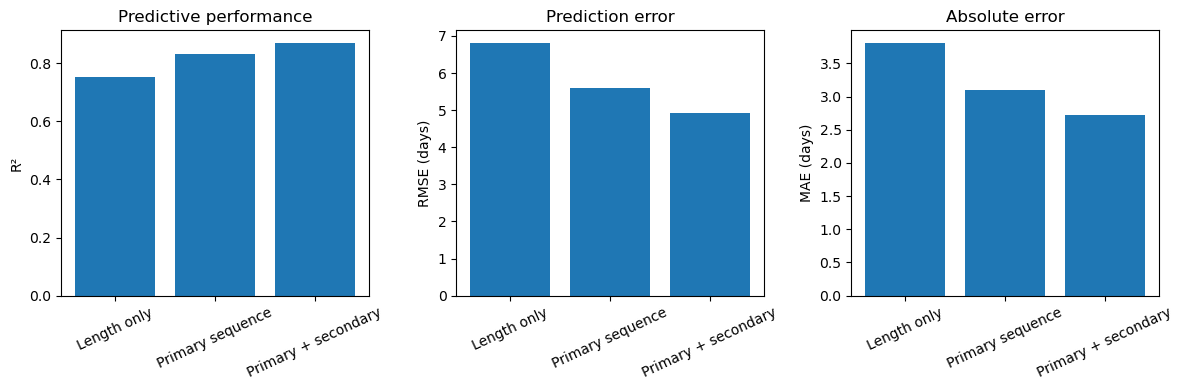

✓ Saved: secondary_structure_ablation.png


In [43]:
# ============================================================================
# SECONDARY-STRUCTURE ABLATION ANALYSIS
# Compare:
#   1) Length only
#   2) Primary-sequence features only
#   3) Primary + secondary-structure features
# Uses the SAME train/test split as the optimized XGBoost analysis
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor


# ----------------------------------------------------------------------------
# 1. Define secondary-structure features
# ----------------------------------------------------------------------------

secondary_features = [
    'max_stem_length',
    'avg_stem_length',
    'total_loops',
    'max_loop_size',
    'GT_pairs',
    'pairing_rate',
    'stem_count',
    'MFE'
]

# X is the 95-feature dataframe already used above
all_feature_cols = list(X.columns)

# Primary-sequence features = all features except the 8 secondary features
primary_features = [
    c for c in all_feature_cols
    if c not in secondary_features
]

print("=" * 70)
print("SECONDARY-STRUCTURE ABLATION ANALYSIS")
print("=" * 70)

print(f"Total features: {len(all_feature_cols)}")
print(f"Primary-sequence features: {len(primary_features)}")
print(f"Secondary-structure features: {len(secondary_features)}")

assert len(all_feature_cols) == 95, \
    f"Expected 95 total features, found {len(all_feature_cols)}"

assert len(primary_features) == 87, \
    f"Expected 87 primary features, found {len(primary_features)}"


# ----------------------------------------------------------------------------
# 2. Define three feature sets
# ----------------------------------------------------------------------------

feature_sets = {
    'Length only': ['log_length'],
    'Primary sequence': primary_features,
    'Primary + secondary': all_feature_cols
}


# ----------------------------------------------------------------------------
# 3. Extract optimized XGBoost parameters
#    Use the SAME tuned hyperparameters for all three ablation models
# ----------------------------------------------------------------------------

best_params = random_search.best_params_.copy()

# remove "model__" prefix
xgb_params = {
    k.replace('model__', ''): v
    for k, v in best_params.items()
}

# fixed parameters
xgb_params.update({
    'random_state': 42,
    'objective': 'reg:squarederror',
    'n_jobs': -1,
    'verbosity': 0
})

print("\nUsing optimized XGBoost parameters:")
for k, v in xgb_params.items():
    print(f"  {k}: {v}")


# ----------------------------------------------------------------------------
# 4. Train and evaluate each feature set
# ----------------------------------------------------------------------------

ablation_results = []

for name, cols in feature_sets.items():

    print("\n" + "-" * 70)
    print(f"Feature set: {name}")
    print(f"Number of features: {len(cols)}")

    # IMPORTANT:
    # reuse the SAME train_idx / val_idx generated previously
    X_train_ab = X.iloc[train_idx][cols].reset_index(drop=True)
    X_test_ab  = X.iloc[val_idx][cols].reset_index(drop=True)

    y_train_ab = y.iloc[train_idx].reset_index(drop=True)
    y_test_ab  = y.iloc[val_idx].reset_index(drop=True)

    model = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(**xgb_params))
    ])

    model.fit(X_train_ab, y_train_ab)

    y_pred_ab = model.predict(X_test_ab)

    r2 = r2_score(y_test_ab, y_pred_ab)
    rmse = np.sqrt(mean_squared_error(y_test_ab, y_pred_ab))
    mae = mean_absolute_error(y_test_ab, y_pred_ab)

    ablation_results.append({
        'Feature_set': name,
        'N_features': len(cols),
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"R²   = {r2:.4f}")
    print(f"RMSE = {rmse:.4f} days")
    print(f"MAE  = {mae:.4f} days")


# ----------------------------------------------------------------------------
# 5. Results table
# ----------------------------------------------------------------------------

ablation_df = pd.DataFrame(ablation_results)

print("\n" + "=" * 70)
print("ABLATION RESULTS")
print("=" * 70)
print(ablation_df.to_string(index=False))

ablation_df.to_csv(
    'secondary_structure_ablation_results.csv',
    index=False
)

print("\n✓ Saved: secondary_structure_ablation_results.csv")


# ----------------------------------------------------------------------------
# 6. Quantify incremental contribution of secondary structure
# ----------------------------------------------------------------------------

primary_row = ablation_df[
    ablation_df['Feature_set'] == 'Primary sequence'
].iloc[0]

full_row = ablation_df[
    ablation_df['Feature_set'] == 'Primary + secondary'
].iloc[0]

delta_r2 = full_row['R2'] - primary_row['R2']
delta_rmse = primary_row['RMSE'] - full_row['RMSE']
delta_mae = primary_row['MAE'] - full_row['MAE']

print("\nIncremental contribution of secondary-structure features:")
print(f"ΔR²   = {delta_r2:+.4f}")
print(f"ΔRMSE = {delta_rmse:+.4f} days")
print(f"ΔMAE  = {delta_mae:+.4f} days")


# ----------------------------------------------------------------------------
# 7. Plot
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

labels = ablation_df['Feature_set']

axes[0].bar(labels, ablation_df['R2'])
axes[0].set_ylabel('R²')
axes[0].set_title('Predictive performance')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(labels, ablation_df['RMSE'])
axes[1].set_ylabel('RMSE (days)')
axes[1].set_title('Prediction error')
axes[1].tick_params(axis='x', rotation=25)

axes[2].bar(labels, ablation_df['MAE'])
axes[2].set_ylabel('MAE (days)')
axes[2].set_title('Absolute error')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(
    'secondary_structure_ablation.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✓ Saved: secondary_structure_ablation.png")

#### 3.6 Feature Importance Analysis (XGBoost)


CREATING COMBINED FIGURE WITH ALL PLOTS (WIDE LAYOUT)
Generating Feature Importance...
Generating SHAP Feature Importance...
Generating SHAP Impact Distribution...
Generating SHAP Waterfall Plot...
Generating SHAP Dependence Plots...
  Dependence plot: MFE
  Dependence plot: log_length
  Dependence plot: stem_count

Combining all plots into one wide figure...
  Loaded: feature_importance.png (2384x734)
  Loaded: shap_importance.png (1185x1110)
  Loaded: shap_beeswarm.png (1151x1109)
  Loaded: shap_waterfall.png (1196x959)
  Loaded: shap_dependence_1.png (1075x735)
  Loaded: shap_dependence_2.png (1075x735)
  Loaded: shap_dependence_3.png (1075x735)

✅ Combined figure saved as 'combined_feature_importance_shap_wide.png'
   Size: 2400x2056 pixels (WIDE layout)
   Layout: 1 row (full width) + 3 columns + dependence plots


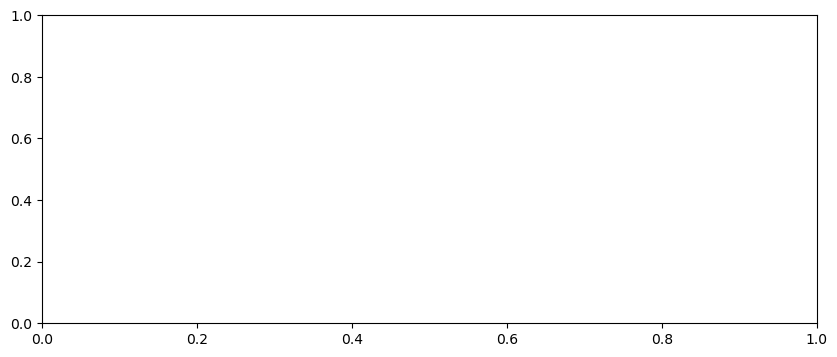

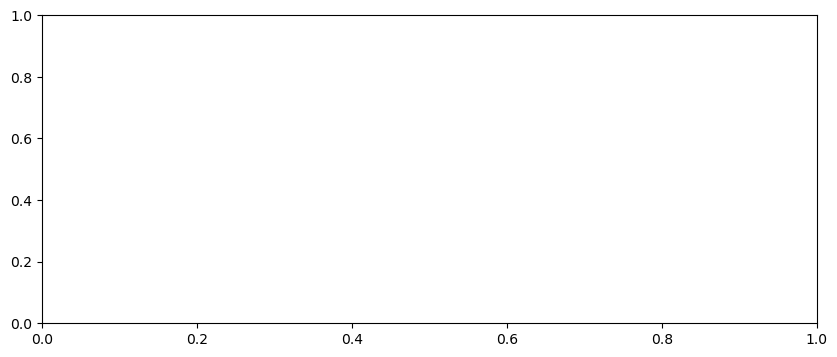

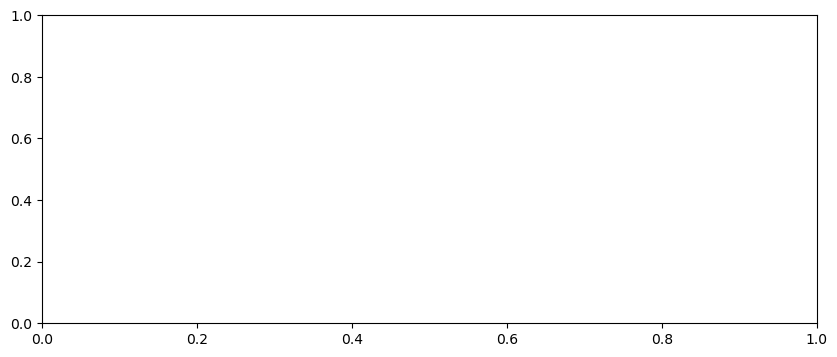

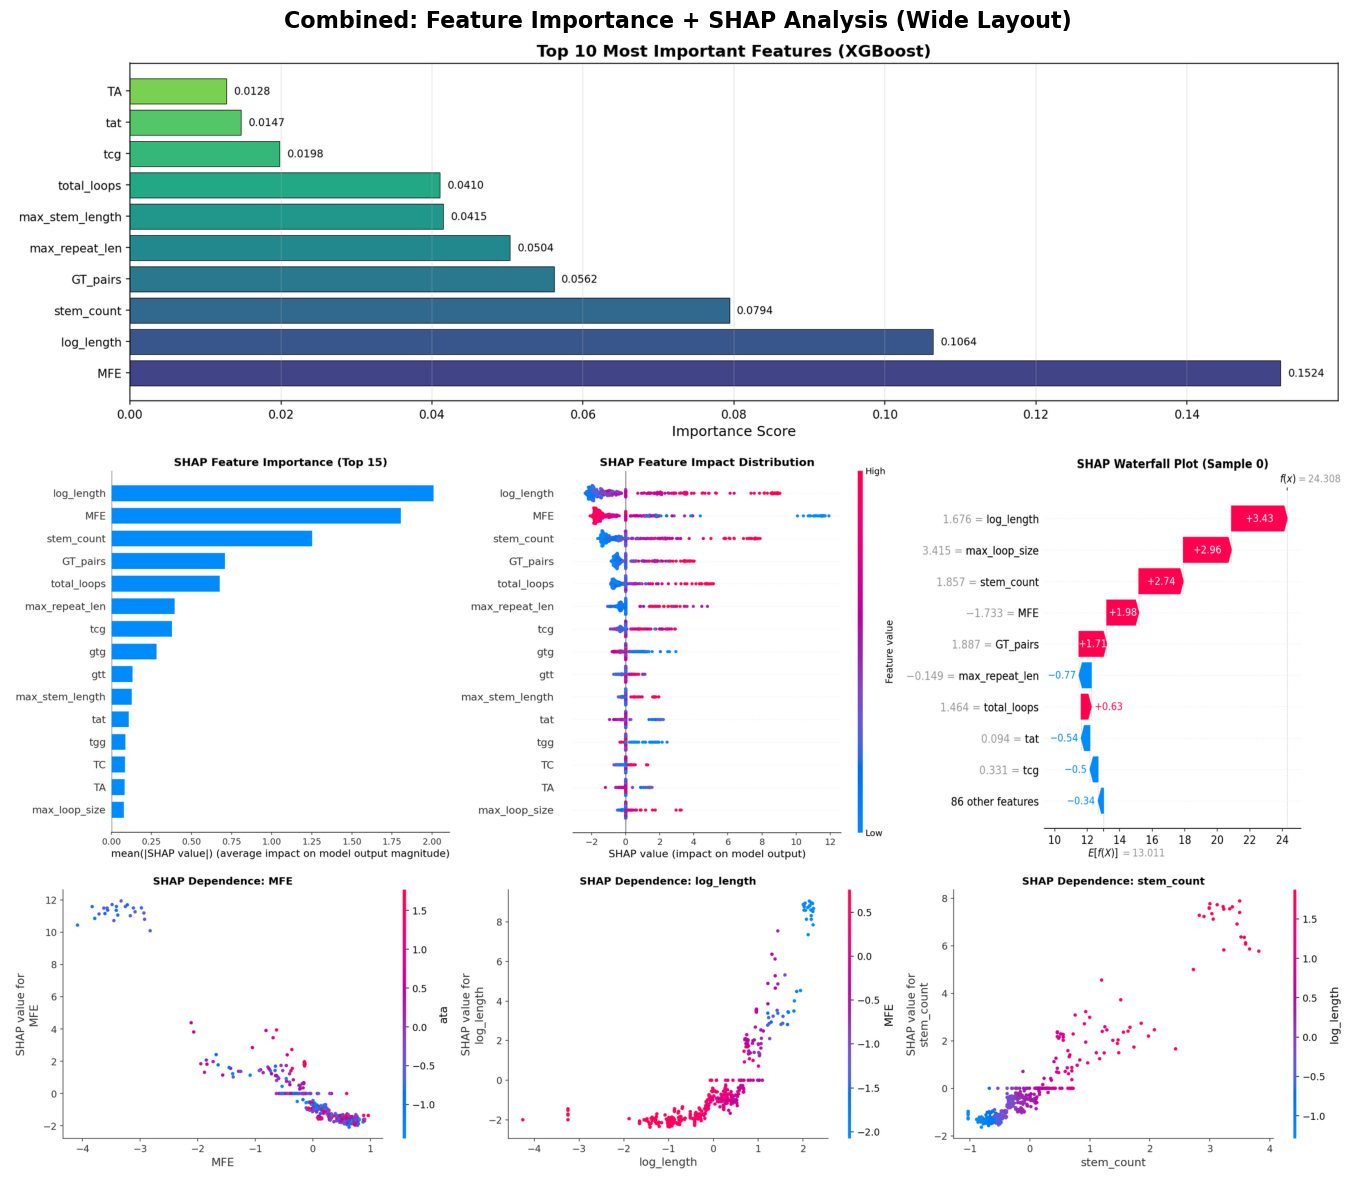


✅ All plots combined successfully in WIDE layout!


In [109]:
# ============================================================================
# COMBINED FIGURE: Feature Importance + SHAP Plots (WIDE LAYOUT)
# Clean approach using individual saves and combining
# ============================================================================
print("\n" + "=" * 70)
print("CREATING COMBINED FIGURE WITH ALL PLOTS (WIDE LAYOUT)")
print("=" * 70)

# Create a temporary directory for individual plots
temp_dir = 'temp_plots'
os.makedirs(temp_dir, exist_ok=True)

# ============================================================================
# 1. FEATURE IMPORTANCE PLOT (Top 10) - WIDER
# ============================================================================
print("Generating Feature Importance...")
fig1, ax1 = plt.subplots(figsize=(16, 5))  # Wider, shorter
top10_features = importance_df.head(10).copy()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top10_features)))
bars = ax1.barh(top10_features['Feature'], top10_features['Importance'], 
                color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Importance Score', fontsize=12)
ax1.set_title('Top 10 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, (bar, val) in enumerate(zip(bars, top10_features['Importance'])):
    ax1.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{temp_dir}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================================
# 2. SHAP FEATURE IMPORTANCE (Bar plot) - WIDER
# ============================================================================
print("Generating SHAP Feature Importance...")
fig2, ax2 = plt.subplots(figsize=(12, 5))  # Wider, shorter
shap.summary_plot(
    shap_values_reg,
    X_val_processed,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{temp_dir}/shap_importance.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================================
# 3. SHAP IMPACT DISTRIBUTION (Beeswarm) - WIDER
# ============================================================================
print("Generating SHAP Impact Distribution...")
fig3, ax3 = plt.subplots(figsize=(12, 5))  # Wider, shorter
shap.summary_plot(
    shap_values_reg,
    X_val_processed,
    feature_names=X.columns.tolist(),
    max_display=15,
    show=False
)
plt.title('SHAP Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{temp_dir}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================================
# 4. SHAP WATERFALL PLOT - WIDER
# ============================================================================
print("Generating SHAP Waterfall Plot...")
fig4, ax4 = plt.subplots(figsize=(12, 5))  # Wider, shorter
try:
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_reg[0],
            base_values=explainer_reg.expected_value,
            data=X_val_processed[0],
            feature_names=X.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title('SHAP Waterfall Plot (Sample 0)', fontsize=14, fontweight='bold')
except Exception as e:
    ax4.text(0.5, 0.5, f'Waterfall plot not available', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    plt.title('SHAP Waterfall Plot (Unavailable)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{temp_dir}/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================================
# 5. SHAP DEPENDENCE PLOTS (Top 3 features) - WIDER
# ============================================================================
print("Generating SHAP Dependence Plots...")
dependence_files = []
top_3_features = importance_df.head(3)['Feature'].tolist()

for i, feature in enumerate(top_3_features):
    print(f"  Dependence plot: {feature}")
    fig5, ax5 = plt.subplots(figsize=(10, 4))  # Wider, shorter
    try:
        shap.dependence_plot(
            feature,
            shap_values_reg,
            X_val_processed,
            feature_names=X.columns.tolist(),
            show=False
        )
        plt.title(f'SHAP Dependence: {feature}', fontsize=12, fontweight='bold')
    except Exception as e:
        ax5.text(0.5, 0.5, f'Plot not available', 
                 ha='center', va='center', transform=ax5.transAxes, fontsize=10)
        plt.title(f'SHAP Dependence: {feature} (Unavailable)', fontsize=12)
    plt.tight_layout()
    filename = f'{temp_dir}/shap_dependence_{i+1}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    dependence_files.append(filename)

# ============================================================================
# 6. COMBINE ALL IMAGES INTO ONE WIDE FIGURE
# ============================================================================
print("\nCombining all plots into one wide figure...")

# Load all images
img_files = [
    f'{temp_dir}/feature_importance.png',
    f'{temp_dir}/shap_importance.png',
    f'{temp_dir}/shap_beeswarm.png',
    f'{temp_dir}/shap_waterfall.png'
] + dependence_files

# Load images and get dimensions
images = []
for f in img_files:
    if os.path.exists(f):
        img = Image.open(f)
        images.append(img)
        print(f"  Loaded: {os.path.basename(f)} ({img.size[0]}x{img.size[1]})")

if images:
    # ============================================================================
    # WIDE LAYOUT: 
    # Row 1: Feature Importance (full width) - short
    # Row 2: SHAP Importance | SHAP Beeswarm | SHAP Waterfall (3 columns)
    # Row 3: Dependence plots (all next to each other)
    # ============================================================================
    
    # Get dimensions
    widths = [img.width for img in images]
    heights = [img.height for img in images]
    
    # Target total width (wide)
    target_width = 2400  # Wider than before
    
    # Row 1: Feature importance (full width)
    row1_height = int(heights[0] * (target_width / widths[0]))
    row1_width = target_width
    
    # Row 2: 3 columns - images 1, 2, 3
    row2_height = int(max(heights[1], heights[2], heights[3]) * (target_width / 3 / max(widths[1:4])))
    col_width = target_width // 3
    
    # Row 3: Dependence plots - images 4, 5, 6 (all next to each other)
    if len(images) > 4:
        dep_count = len(images) - 4
        dep_col_width = target_width // dep_count
        row3_height = int(max(heights[4:]) * (dep_col_width / max(widths[4:])))
    else:
        row3_height = 0
    
    # Calculate total height (shorter than before)
    total_height = row1_height + row2_height + row3_height + 30  # less padding
    total_width = target_width
    
    # Create blank canvas
    combined = Image.new('RGB', (total_width, total_height), color='white')
    
    y_offset = 0
    
    # ========================================================================
    # ROW 1: Feature Importance (full width)
    # ========================================================================
    img_resized = images[0].resize((row1_width, row1_height), Image.Resampling.LANCZOS)
    combined.paste(img_resized, (0, y_offset))
    y_offset += row1_height + 10
    
    # ========================================================================
    # ROW 2: SHAP Importance | SHAP Beeswarm | SHAP Waterfall (3 columns)
    # ========================================================================
    for i in range(1, 4):
        if i < len(images):
            img_resized = images[i].resize((col_width, row2_height), Image.Resampling.LANCZOS)
            x_offset = (i - 1) * col_width
            combined.paste(img_resized, (x_offset, y_offset))
    y_offset += row2_height + 10
    
    # ========================================================================
    # ROW 3: SHAP Dependence plots (all next to each other)
    # ========================================================================
    if len(images) > 4:
        for i in range(4, len(images)):
            img_resized = images[i].resize((dep_col_width, row3_height), Image.Resampling.LANCZOS)
            x_offset = (i - 4) * dep_col_width
            combined.paste(img_resized, (x_offset, y_offset))
    
    # Save combined image
    combined.save('combined_feature_importance_shap_wide.png', quality=95)
    print(f"\n✅ Combined figure saved as 'combined_feature_importance_shap_wide.png'")
    print(f"   Size: {combined.size[0]}x{combined.size[1]} pixels (WIDE layout)")
    print(f"   Layout: 1 row (full width) + 3 columns + dependence plots")
    
    # Display combined image
    plt.figure(figsize=(24, 12))  # Wider figure
    plt.imshow(combined)
    plt.axis('off')
    plt.title('Combined: Feature Importance + SHAP Analysis (Wide Layout)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No images were generated. Check your SHAP analysis.")

# ============================================================================
# 7. CLEAN UP TEMP FILES (Optional)
# ============================================================================
# Uncomment to clean up temporary files
# import shutil
# shutil.rmtree(temp_dir)
# print("✅ Temporary files cleaned up.")

print("\n✅ All plots combined successfully in WIDE layout!")

## 4. Model Evaluation
#### Model Evaluation: Classification Metrics

While our primary task is regression (predicting synthesis duration in days), we also evaluate the model's ability to distinguish between "short" and "long" synthesis times. This binary classification provides additional insight into the model's practical utility—for example, whether it can reliably flag sequences that are likely to exceed a certain production threshold.

#### Evaluation Approach

To convert the regression predictions into a binary classification task, we use the median synthesis duration as the decision threshold. Sequences with predicted durations above the median are classified as "Long" (Class 1), while those below or equal to the median are classified as "Short" (Class 0). This threshold is intuitive and ensures balanced class distributions.

#### 4.1 Metrics Computed

We calculate the following standard classification metrics:

- **Confusion Matrix**: A 2×2 table showing true positives, true negatives, false positives, and false negatives.
- **Accuracy**: Overall proportion of correct predictions.
- **Precision**: Proportion of predicted "Long" sequences that are actually "Long".
- **Recall (Sensitivity)**: Proportion of actual "Long" sequences that were correctly identified.
- **F1 Score**: Harmonic mean of precision and recall, providing a balanced measure of model performance.

#### 4.2 ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate against the False Positive Rate across all possible thresholds. The Area Under the Curve (AUC) provides a single summary measure—values closer to 1.0 indicate excellent discriminative ability.

- **AUC ≥ 0.9**: Excellent
- **AUC 0.8–0.9**: Good
- **AUC 0.7–0.8**: Fair
- **AUC 0.6–0.7**: Poor
- **AUC 0.5–0.6**: Fail (no better than random)

#### 4.3 Precision-Recall Curve

The Precision-Recall curve is particularly informative when dealing with imbalanced datasets. It plots precision against recall at various threshold settings. The Average Precision (AP) score summarizes this curve and is especially useful when the positive class (Long) is of primary interest.

### Interpretation Guidelines

- **High Precision** indicates that when the model predicts "Long", it is usually correct (few false alarms).
- **High Recall** indicates that the model captures most of the actual "Long" sequences (few missed cases).
- **High F1 Score** balances both precision and recall, making it a good single metric for overall classification performance.
- **High AUC** indicates the model can reliably separate Short from Long sequences across all threshold settings.

The optimal threshold is identified using Youden's J statistic (J = TPR - FPR), which maximizes the sum of sensitivity and specificity. This threshold can be used in production to set a practical decision boundary for flagging difficult sequences.

The code below generates these metrics and visualizations on the validation set.

MODEL EVALUATION
Validation set size: 478
Features shape: (478, 95)
Predictions shape: (478,)

BINARY CLASSIFICATION (Short vs Long)
Threshold (median): 7.00 days
  Class 0 = Short (≤ median)
  Class 1 = Long (> median)
y_true_binary shape: (478,)
y_pred_binary shape: (478,)

True Positives (TP):  216  (predicted Long, actual Long)
True Negatives (TN):  203  (predicted Short, actual Short)
False Positives (FP): 53  (predicted Long, actual Short)
False Negatives (FN): 6  (predicted Short, actual Long)

Metrics (Short vs Long):
   Accuracy:  0.8766
   Precision: 0.8030
   Recall:    0.9730
   F1:        0.8798


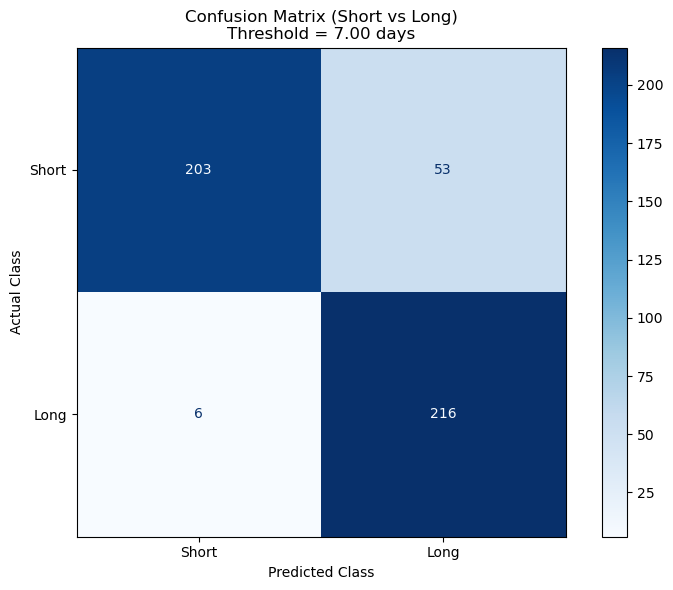

✅ 2x2 Confusion matrix saved as 'confusion_matrix_2x2.png'

ROC CURVE AND AUC
AUC Score: 0.9719

Interpretation of AUC:
  🟢 Excellent (0.9-1.0)

Optimal threshold (Youden's J): 8.4085
  True Positive Rate at optimal threshold: 0.9279
  False Positive Rate at optimal threshold: 0.0781


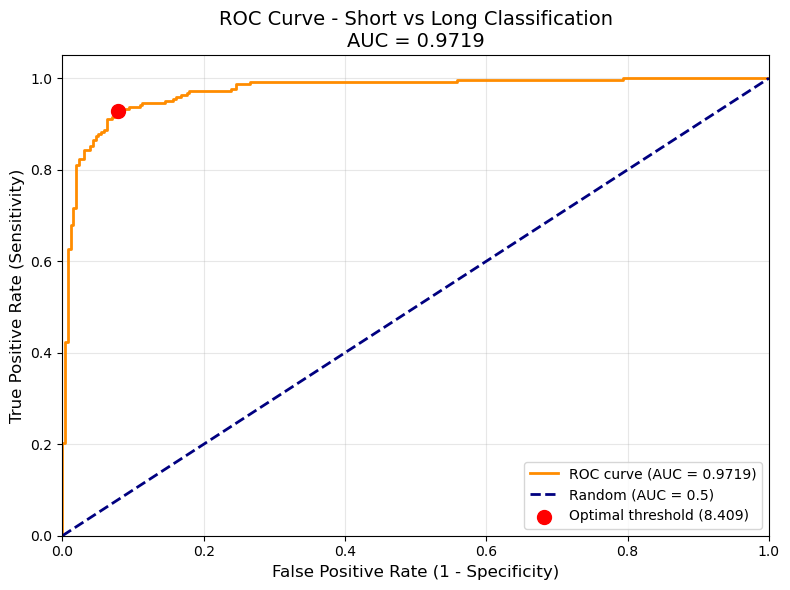

✅ ROC curve saved as 'roc_curve.png'

PRECISION-RECALL CURVE
Average Precision (AP): 0.9672


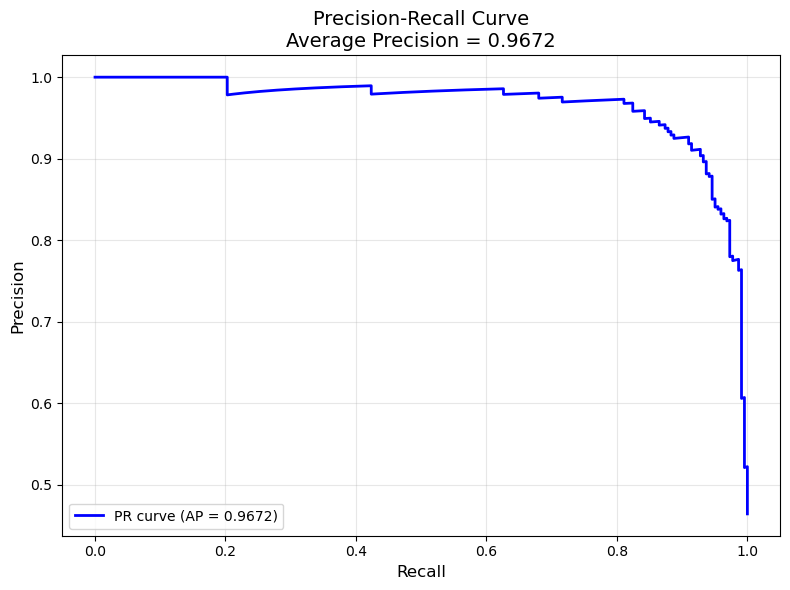

✅ Precision-Recall curve saved as 'precision_recall_curve.png'

FINAL SUMMARY

📊 Total validation samples: 478
   Threshold (median): 7.00 days

📊 Confusion Matrix:
   TP: 216  |  FP: 53
   FN: 6  |  TN: 203

📊 Classification Metrics:
   Accuracy:  0.8766
   Precision: 0.8030
   Recall:    0.9730
   F1 Score:  0.8798
   AUC Score: 0.9719
   Avg Precision: 0.9672

📁 Files Saved:
   ✅ confusion_matrix_2x2.png
   ✅ roc_curve.png
   ✅ precision_recall_curve.png

✅ Evaluation complete!


In [111]:
# ============================================================================
# EVALUATION: Confusion Matrix, Accuracy, Precision, Recall, F1, ROC Curve
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, 
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

# ============================================================================
# 1. MAKE SURE PREDICTIONS EXIST
# ============================================================================
# Your model is already trained: best_xgb
# Your validation data: X_val, y_val

print(f"Validation set size: {len(y_val)}")
print(f"Features shape: {X_val.shape}")

# Make predictions on validation set
y_pred = best_xgb.predict(X_val)
print(f"Predictions shape: {y_pred.shape}")

# ============================================================================
# 2. BINARY CLASSIFICATION (Short vs Long based on median)
# ============================================================================
print("\n" + "=" * 70)
print("BINARY CLASSIFICATION (Short vs Long)")
print("=" * 70)

# Use median as threshold
median_duration = np.median(y_val)
print(f"Threshold (median): {median_duration:.2f} days")
print("  Class 0 = Short (≤ median)")
print("  Class 1 = Long (> median)")

# Create binary labels
y_true_binary = (y_val > median_duration).astype(int)
y_pred_binary = (y_pred > median_duration).astype(int)

print(f"y_true_binary shape: {y_true_binary.shape}")
print(f"y_pred_binary shape: {y_pred_binary.shape}")

# Check if any predictions exist
if len(y_pred_binary) == 0:
    raise ValueError("No predictions generated! Check your model.")

# Confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 50)
print(f"True Positives (TP):  {tp}  (predicted Long, actual Long)")
print(f"True Negatives (TN):  {tn}  (predicted Short, actual Short)")
print(f"False Positives (FP): {fp}  (predicted Long, actual Short)")
print(f"False Negatives (FN): {fn}  (predicted Short, actual Long)")
print("=" * 50)

# Calculate metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

print(f"\nMetrics (Short vs Long):")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1:        {f1:.4f}")

# ============================================================================
# 3. CONFUSION MATRIX PLOT
# ============================================================================
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Short', 'Long'])
disp.plot(ax=ax_cm, cmap='Blues', values_format='d')
ax_cm.set_title(f'Confusion Matrix (Short vs Long)\nThreshold = {median_duration:.2f} days')
ax_cm.set_xlabel('Predicted Class')
ax_cm.set_ylabel('Actual Class')
plt.tight_layout()
plt.savefig('confusion_matrix_2x2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 2x2 Confusion matrix saved as 'confusion_matrix_2x2.png'")

# ============================================================================
# 4. ROC CURVE AND AUC
# ============================================================================
print("\n" + "=" * 70)
print("ROC CURVE AND AUC")
print("=" * 70)

# Use the predicted values as scores (higher = more likely "Long")
y_scores = y_pred

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_binary, y_scores)
auc_score = roc_auc_score(y_true_binary, y_scores)

print(f"AUC Score: {auc_score:.4f}")

# Interpretation
print("\nInterpretation of AUC:")
if auc_score >= 0.9:
    print("  🟢 Excellent (0.9-1.0)")
elif auc_score >= 0.8:
    print("  🟢 Good (0.8-0.9)")
elif auc_score >= 0.7:
    print("  🟡 Fair (0.7-0.8)")
elif auc_score >= 0.6:
    print("  🟡 Poor (0.6-0.7)")
else:
    print("  🔴 Fail (0.5-0.6)")

# Find optimal threshold (Youden's J statistic)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"  True Positive Rate at optimal threshold: {optimal_tpr:.4f}")
print(f"  False Positive Rate at optimal threshold: {optimal_fpr:.4f}")

# Plot ROC curve
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')

# Mark optimal threshold
ax_roc.scatter(optimal_fpr, optimal_tpr, color='red', s=100, 
               label=f'Optimal threshold ({optimal_threshold:.3f})', zorder=5)

ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax_roc.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax_roc.set_title(f'ROC Curve - Short vs Long Classification\nAUC = {auc_score:.4f}', fontsize=14)
ax_roc.legend(loc="lower right")
ax_roc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved as 'roc_curve.png'")

# ============================================================================
# 5. PRECISION-RECALL CURVE
# ============================================================================
print("\n" + "=" * 70)
print("PRECISION-RECALL CURVE")
print("=" * 70)

precision_vals, recall_vals, _ = precision_recall_curve(y_true_binary, y_scores)
avg_precision = average_precision_score(y_true_binary, y_scores)

print(f"Average Precision (AP): {avg_precision:.4f}")

fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
ax_pr.plot(recall_vals, precision_vals, color='blue', lw=2, 
           label=f'PR curve (AP = {avg_precision:.4f})')
ax_pr.set_xlabel('Recall', fontsize=12)
ax_pr.set_ylabel('Precision', fontsize=12)
ax_pr.set_title(f'Precision-Recall Curve\nAverage Precision = {avg_precision:.4f}', fontsize=14)
ax_pr.legend(loc="lower left")
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Precision-Recall curve saved as 'precision_recall_curve.png'")

# ============================================================================
# 6. FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"\n📊 Total validation samples: {len(y_val)}")
print(f"   Threshold (median): {median_duration:.2f} days")

print(f"\n📊 Confusion Matrix:")
print(f"   TP: {tp}  |  FP: {fp}")
print(f"   FN: {fn}  |  TN: {tn}")

print(f"\n📊 Classification Metrics:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1 Score:  {f1:.4f}")
print(f"   AUC Score: {auc_score:.4f}")
print(f"   Avg Precision: {avg_precision:.4f}")

print(f"\n📁 Files Saved:")
print("   ✅ confusion_matrix_2x2.png")
print("   ✅ roc_curve.png")
print("   ✅ precision_recall_curve.png")

print("\n✅ Evaluation complete!")

## 4 (cont') Evaluation Results Summary

The classification evaluation provides a practical perspective on the model's utility for real-world gene synthesis workflows.

### Key Insights

The confusion matrix reveals how well the model distinguishes between short and long synthesis times. A high number of true positives and true negatives indicates reliable classification, while false positives (sequences predicted as "Long" but actually "Short") and false negatives (sequences predicted as "Short" but actually "Long") reveal the model's failure modes.

### Practical Implications

- **High Recall**: Important for identifying genuinely difficult sequences that might cause production delays. This helps manufacturers proactively allocate resources.
- **High Precision**: Important for avoiding false alarms—sequences flagged as difficult but actually easy. False positives could lead to unnecessary sequence redesign and wasted effort.

### ROC and PR Curves

The ROC curve and AUC score provide a threshold-independent assessment of the model's discriminative ability. The Precision-Recall curve is particularly valuable when the cost of false positives differs from false negatives—a common scenario in industrial settings.

### Optimal Threshold Selection

The Youden's J statistic identifies the threshold that balances sensitivity and specificity. This threshold can be used to automatically flag sequences for review, enabling a "traffic light" system:
- **Green (Short)**: Proceed with standard synthesis
- **Red (Long)**: Flag for sequence optimization prior to synthesis

### Files Generated

This evaluation script produces the following files for inclusion in the manuscript:
- `confusion_matrix_2x2.png` – The 2×2 confusion matrix heatmap
- `roc_curve.png` – The ROC curve with AUC annotation
- `precision_recall_curve.png` – The Precision-Recall curve with AP annotation

These figures provide visual evidence of the model's classification performance and can be included in supplementary materials or the main text as appropriate.
